# Fusion Formula Tabanli Robot Skorlama Pipeline

Bu notebook iki ayri calisma modu sunar:

- `Full Build`: ilk kez SQLite store ve cluster artefact'larini uretir
- `Rescore From Existing Store`: mevcut `fusion_batch_store.sqlite` korunarak sadece skor katmanini yeniden hesaplar

Tum gorsellestirme hucreleri oncesinde artefact readiness kontrolu zorunludur. Eski-yeni uyumsuzluklarda notebook sessiz fallback yapmaz; yonlendirici hata uretir.


In [62]:
import copy
from pathlib import Path

CONFIG = {
    "paths": {
        "input_parquet": "data/datathonFINAL.parquet",
        "clean_output_parquet": "data/datathonFINAL_formula_cleaned.parquet",
        "batch_sqlite_db": "data/fusion_batch_store.sqlite",
        "author_scores_parquet": "data/fusion_author_scores.parquet",
        "scored_messages_parquet": "data/fusion_scored_messages.parquet",
        "manifest_path": "data/fusion_manifest.json",
        "author_feature_stage_parquet": "data/fusion_author_feature_stage.parquet",
    },
    "runtime": {
        "mode": "full",
        "use_model_test_sample": False,
        "model_test_rows": 200_000,
        "build_mode": "lean",
        "batch_size": 250_000,
        "max_batches": None,
        "sample_n_rows": None,
        "overwrite_outputs": True,
        "enable_progress_logs": True,
        "progress_every_batches": 10,
        "top_n_domain_context": 128,
        "author_batch_size": 10_000,
        "message_batch_size": 250_000,
    },
    "semantic_adapter": {
        "enabled": True,
        "selected_model_key": "distil_bot_en",
        "models": {
            "distil_bot_en": {
                "model_name": "junaid1993/distilroberta-bot-detection",
                "supported_languages": ["en"],
            },
            "xlmr_base_multilingual": {
                "model_name": "FacebookAI/xlm-roberta-base",
                "supported_languages": "all",
            },
        },
        "unsupported_language_score": 0.50,
        "max_length": 128,
        "batch_size": 64,
        "device": "mps",
    },
    "thresholds": {
        "min_text_len": 5,
        "rare_language_threshold": 100,
        "long_text_start": 30,
        "hourly_penalty_start": 10,
        "hard_hourly_bot_threshold": 15,
        "language_penalty_start": 4,
        "hard_bot_time_window_sec": 300,
        "hard_bot_repeat_threshold": 5,
        "hard_bot_multi_author_threshold": 2,
        "hard_bot_time_cluster_threshold": 3,
        "spam_repeat_threshold": 3,
        "spam_multi_author_threshold": 2,
        "spam_time_cluster_threshold": 3,
    },
    "rules": {
        "long_text_requires_spam": False,
    },
    "derived_thresholds": {},
    "neutral_score_policy": {
        "neutral_score": 0.50,
        "epsilon": 1e-6,
    },
    "dominant_signal_policy": {
        "enabled": True,
        "threshold": 0.68,
        "scope": {
            "message": True,
            "author": True,
            "semantic": False,
        },
        "mode": "floor",
        "repeat_hard_threshold": 5,
        "repeat_hard_target": "final_score",
    },
    "dynamic_final_weighting": {
        "enabled": True,
        "min_confidence_weight": 0.20,
        "power": 2.0,
        "sigmoid_steepness": 8.0,
    },
    "weights": {
        "behavioral_vs_semantic": {
            "behavioral": 0.50,
            "semantic": 0.50,
        },
        "author_vs_message": {
            "author": 0.70,
            "message": 0.30,
        },
        "author_components": {
            "activity": 0.35,
            "timing": 0.25,
            "repetition": 0.26,
            "diversity": 0.14,
            "metadata": 0.00,
        },
        "message_components": {
            "same_text_repeat": 0.20,
            "spam_pattern": 0.60,
            "hashtag_spam": 0.10,
            "token_repetition": 0.04,
            "long_text": 0.02,
            "keyword_signal": 0.04,
        },
    },
}

CONFIG_MODEL_TEST = copy.deepcopy(CONFIG)
CONFIG_MODEL_TEST["paths"].update({
    "input_parquet": "data/fusion_model_test_input_200k.parquet",
    "clean_output_parquet": "data/fusion_model_test_cleaned_200k.parquet",
    "batch_sqlite_db": "data/fusion_model_test_store_200k.sqlite",
    "author_scores_parquet": "data/fusion_model_test_author_scores.parquet",
    "scored_messages_parquet": "data/fusion_model_test_scored_messages.parquet",
    "manifest_path": "data/fusion_model_test_manifest.json",
    "author_feature_stage_parquet": "data/fusion_model_test_author_feature_stage.parquet",
})
MODEL_TEST_ROWS = int(CONFIG["runtime"]["model_test_rows"])
CONFIG_MODEL_TEST["runtime"].update({
    "mode": "model_test_200k_store",
    "batch_size": MODEL_TEST_ROWS,
    "max_batches": 1,
    "sample_n_rows": MODEL_TEST_ROWS,
    "progress_every_batches": 1,
})

RUN_CONFIG = CONFIG_MODEL_TEST if CONFIG["runtime"]["use_model_test_sample"] else CONFIG

CONFIG


{'paths': {'input_parquet': 'data/datathonFINAL.parquet',
  'clean_output_parquet': 'data/datathonFINAL_formula_cleaned.parquet',
  'batch_sqlite_db': 'data/fusion_batch_store.sqlite',
  'author_scores_parquet': 'data/fusion_author_scores.parquet',
  'scored_messages_parquet': 'data/fusion_scored_messages.parquet',
  'manifest_path': 'data/fusion_manifest.json',
  'author_feature_stage_parquet': 'data/fusion_author_feature_stage.parquet'},
 'runtime': {'mode': 'full',
  'use_model_test_sample': False,
  'model_test_rows': 200000,
  'build_mode': 'lean',
  'batch_size': 250000,
  'max_batches': None,
  'sample_n_rows': None,
  'overwrite_outputs': True,
  'enable_progress_logs': True,
  'progress_every_batches': 10,
  'top_n_domain_context': 128,
  'author_batch_size': 10000,
  'message_batch_size': 250000},
 'semantic_adapter': {'enabled': True,
  'selected_model_key': 'distil_bot_en',
  'models': {'distil_bot_en': {'model_name': 'junaid1993/distilroberta-bot-detection',
    'supported

In [63]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

import formula_scoring_pipeline as formula_scoring_pipeline
importlib.reload(formula_scoring_pipeline)

from formula_scoring_pipeline import (
    assert_artifacts_ready,
    build_qa_tables,
    load_manifest,
    plot_hourly_distribution,
    plot_hourly_penalty_curve,
    plot_sentiment_theme_distributions,
    prepare_single_message_input,
    run_formula_pipeline,
    run_formula_pipeline_two_pass,
    run_rescore_from_existing_store,
    score_single_message,
    validate_scored_outputs,
)


def build_in_memory_run_outputs(result: dict, config: dict) -> tuple[dict, dict, dict]:
    scored_df = result["scored_df"]
    author_scores = result["author_scores"]
    clean_df = result["clean_df"]

    result["scored_preview"] = scored_df.head(20).copy()
    result["summary"]["mode"] = config["runtime"]["mode"]
    result["summary"]["semantic_applied_rows"] = int(clean_df["semantic_model_applied_flag"].sum())
    result["paths"] = {
        "input_parquet": config["paths"]["input_parquet"],
        "clean_output_parquet": config["paths"]["clean_output_parquet"],
        "author_scores_parquet": "in-memory",
        "scored_messages_parquet": "in-memory",
        "manifest_json": "in-memory",
    }

    tables = build_qa_tables(result, config)
    tables["derived_thresholds"] = pd.DataFrame({
        "metric": ["hourly_hard_knee"],
        "value": [config.get("derived_thresholds", {}).get("hourly_hard_knee")],
    })
    tables["semantic_adapter_summary"] = pd.DataFrame([{
        "rows": len(clean_df),
        "avg_roberta_score": clean_df["roberta_score"].mean(),
        "min_roberta_score": clean_df["roberta_score"].min(),
        "max_roberta_score": clean_df["roberta_score"].max(),
        "semantic_applied_rows": result["summary"]["semantic_applied_rows"],
    }])
    tables["hourly_hard_authors"] = author_scores.loc[
        author_scores["author_hard_hourly_flag"].eq(1)
    ].sort_values("max_posts_one_hour", ascending=False).head(50)
    tables["score_bands"] = formula_scoring_pipeline.summarize_score_bands(scored_df)
    tables["keyword_validation"] = formula_scoring_pipeline.validate_keyword_signal(scored_df, config)
    tables["hashtag_spam_examples"] = scored_df.sort_values("hashtag_spam_component", ascending=False).head(20)
    tables["token_spam_examples"] = scored_df.sort_values("token_repetition_component", ascending=False).head(20)

    manifest = {
        "pipeline_version": "in-memory-sample",
        "store_schema_version": "in-memory",
        "score_schema_version": "in-memory",
        "created_at": pd.Timestamp.utcnow().isoformat(),
        "last_rescore_at": None,
        "mode": config["runtime"]["mode"],
        "input_parquet": config["paths"]["input_parquet"],
        "rows": len(clean_df),
    }
    tables["manifest_summary"] = pd.DataFrame(
        [{"field": key, "value": value} for key, value in manifest.items()]
    )
    return result, tables, manifest


def ensure_model_test_input(run_config: dict, full_config: dict) -> Path:
    model_test_input_path = Path(run_config["paths"]["input_parquet"])
    model_test_input_path.parent.mkdir(parents=True, exist_ok=True)

    if run_config["runtime"].get("overwrite_outputs", True) or not model_test_input_path.exists():
        source_input_path = Path(full_config["paths"]["input_parquet"])
        first_batch = next(
            pq.ParquetFile(source_input_path).iter_batches(
                batch_size=run_config["runtime"]["sample_n_rows"]
            )
        )
        first_table = pa.Table.from_batches([first_batch])
        pq.write_table(first_table, model_test_input_path, compression="snappy")
    return model_test_input_path


## Input Kontrolu

Veri kaynagini, satir sayisini ve runtime ayarlarini burada kontrol edin.


In [64]:
RUN_CONFIG = CONFIG_MODEL_TEST if CONFIG["runtime"]["use_model_test_sample"] else CONFIG
input_path = Path(RUN_CONFIG["paths"]["input_parquet"])
source_input_path = Path(CONFIG["paths"]["input_parquet"])

if CONFIG["runtime"]["use_model_test_sample"]:
    planned_rows = RUN_CONFIG["runtime"]["sample_n_rows"]
    inspect_path = input_path if input_path.exists() else source_input_path
else:
    planned_rows = None
    inspect_path = input_path

parquet_file = pq.ParquetFile(inspect_path)

print(f"selected_mode={RUN_CONFIG['runtime']['mode']}")
print(f"input={input_path}")
print(f"inspect_input={inspect_path}")
print(f"inspect_rows={parquet_file.metadata.num_rows:,}")
print(f"selected_rows={planned_rows if planned_rows is not None else parquet_file.metadata.num_rows:,}")
print(f"row_groups={parquet_file.metadata.num_row_groups}")
print(RUN_CONFIG)


selected_mode=full
input=data/datathonFINAL.parquet
inspect_input=data/datathonFINAL.parquet
inspect_rows=5,004,813
selected_rows=5,004,813
row_groups=528
{'paths': {'input_parquet': 'data/datathonFINAL.parquet', 'clean_output_parquet': 'data/datathonFINAL_formula_cleaned.parquet', 'batch_sqlite_db': 'data/fusion_batch_store.sqlite', 'author_scores_parquet': 'data/fusion_author_scores.parquet', 'scored_messages_parquet': 'data/fusion_scored_messages.parquet', 'manifest_path': 'data/fusion_manifest.json', 'author_feature_stage_parquet': 'data/fusion_author_feature_stage.parquet'}, 'runtime': {'mode': 'full', 'use_model_test_sample': False, 'model_test_rows': 200000, 'build_mode': 'lean', 'batch_size': 250000, 'max_batches': None, 'sample_n_rows': None, 'overwrite_outputs': True, 'enable_progress_logs': True, 'progress_every_batches': 10, 'top_n_domain_context': 128, 'author_batch_size': 10000, 'message_batch_size': 250000}, 'semantic_adapter': {'enabled': True, 'selected_model_key': 'di

## Selected Pipeline Run

`CONFIG["runtime"]["use_model_test_sample"]` true ise 200K sample store build kosar. False ise full batch build kosar.


In [65]:
RUN_CONFIG = CONFIG_MODEL_TEST if CONFIG["runtime"]["use_model_test_sample"] else CONFIG

if CONFIG["runtime"]["use_model_test_sample"]:
    ensure_model_test_input(RUN_CONFIG, CONFIG)

result = run_formula_pipeline_two_pass(RUN_CONFIG)
tables = result["tables"]
manifest = result.get("manifest")

print("pipeline completed")
print({
    "mode": RUN_CONFIG["runtime"]["mode"],
    "input": RUN_CONFIG["paths"]["input_parquet"],
    "clean_rows": result["summary"].get("clean_rows"),
    "semantic_applied_rows": result["summary"].get("semantic_applied_rows"),
})


[06:33:26] [PIPELINE] full build started build_mode=lean


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

[06:41:17] [PASS1] batch=1 raw_rows=250,000 clean_rows=249,965 duplicates_removed=35 semantic_applied_rows=178,738 db_size_mb=185.0 elapsed_min=7.85
[08:00:36] [PASS1] batch=10 raw_rows=2,500,000 clean_rows=2,499,651 duplicates_removed=349 semantic_applied_rows=1,792,718 db_size_mb=1876.5 elapsed_min=87.17
[09:24:25] [PASS1] batch=20 raw_rows=5,000,000 clean_rows=4,999,249 duplicates_removed=751 semantic_applied_rows=3,640,819 db_size_mb=3778.5 elapsed_min=170.99
[09:24:35] [CLUSTERS] materializing text_clusters and text_window_clusters
[09:24:54] [CLUSTERS] cluster tables ready
[09:24:56] [PASS2_AUTHOR_STAGE] author_batches=1 staged_authors=10,000
[09:25:13] [PASS2_AUTHOR_STAGE] author_batches=10 staged_authors=100,000
[09:25:31] [PASS2_AUTHOR_STAGE] author_batches=20 staged_authors=200,000
[09:25:50] [PASS2_AUTHOR_STAGE] author_batches=30 staged_authors=300,000
[09:26:08] [PASS2_AUTHOR_STAGE] author_batches=40 staged_authors=400,000
[09:26:26] [PASS2_AUTHOR_STAGE] author_batches=50 s

## Recompute / Rescore Selected Data

Sample modu açıksa 200K sample store üzerinden rescore çalışır. Full mod açıksa mevcut SQLite store üzerinden rescore çalışır.


In [66]:
RUN_CONFIG = CONFIG_MODEL_TEST if CONFIG["runtime"]["use_model_test_sample"] else CONFIG

if CONFIG["runtime"]["use_model_test_sample"]:
    ensure_model_test_input(RUN_CONFIG, CONFIG)

result = run_rescore_from_existing_store(RUN_CONFIG)
tables = result["tables"]
manifest = result.get("manifest")
print("rescore completed")
print(result["paths"])


[09:31:21] [PIPELINE] rescore from existing store started
[09:31:23] [PASS2_AUTHOR_STAGE] author_batches=1 staged_authors=10,000
[09:31:40] [PASS2_AUTHOR_STAGE] author_batches=10 staged_authors=100,000
[09:31:59] [PASS2_AUTHOR_STAGE] author_batches=20 staged_authors=200,000
[09:32:18] [PASS2_AUTHOR_STAGE] author_batches=30 staged_authors=300,000
[09:32:36] [PASS2_AUTHOR_STAGE] author_batches=40 staged_authors=400,000
[09:32:55] [PASS2_AUTHOR_STAGE] author_batches=50 staged_authors=500,000
[09:33:13] [PASS2_AUTHOR_STAGE] author_batches=60 staged_authors=600,000
[09:33:32] [PASS2_AUTHOR_STAGE] author_batches=70 staged_authors=700,000
[09:33:50] [PASS2_AUTHOR_STAGE] author_batches=80 staged_authors=800,000
[09:34:09] [PASS2_AUTHOR_STAGE] author_batches=90 staged_authors=900,000
[09:34:27] [PASS2_AUTHOR_STAGE] author_batches=100 staged_authors=1,000,000
[09:34:46] [PASS2_AUTHOR_STAGE] author_batches=110 staged_authors=1,100,000
[09:35:04] [PASS2_AUTHOR_STAGE] author_batches=120 staged_auth

## Artefact Readiness Check

Bu hucre tum gorsellestirme ve tablo hucrelerinden once calismalidir. Burasi manifest, SQLite store ve scored outputs uyumlulugunu siki sekilde dogrular.


In [67]:
result = assert_artifacts_ready(result, RUN_CONFIG)
tables = result["tables"]
manifest = result["manifest"]

print("artifacts ready")
print({
    "pipeline_version": manifest["pipeline_version"],
    "store_schema_version": manifest["store_schema_version"],
    "score_schema_version": manifest["score_schema_version"],
    "created_at": manifest["created_at"],
    "last_rescore_at": manifest.get("last_rescore_at"),
})


artifacts ready
{'pipeline_version': 'fusion-2026-04-27', 'store_schema_version': 'store-v2', 'score_schema_version': 'score-v5', 'created_at': '2026-04-27T06:31:21.654812+00:00', 'last_rescore_at': '2026-04-27T06:37:49.685618+00:00'}


## Manifest Ozeti

In [68]:
tables["manifest_summary"]

,field,value
0,pipeline_version,fusion-2026-04-27
1,store_schema_version,store-v2
2,score_schema_version,score-v5
3,store_schema_fingerprint,2b0c4efa668b201674a0bf6db3e711402376a8581ca47d...
4,score_schema_fingerprint,0aa936d01ce003e95503cf03614c944978f36ee0187e4f...
5,created_at,2026-04-27T06:31:21.654812+00:00
6,last_rescore_at,2026-04-27T06:37:49.685618+00:00
7,config_hash_for_store,950c26023968026267b6c6f0e0fe556c31d6066feb30bd...
8,config_hash_for_scoring,4faf1d7a4668da1da856e132879779c7eb24f51174cddf...
9,hourly_hard_knee,15


In [69]:
manifest

{'pipeline_version': 'fusion-2026-04-27',
 'store_schema_version': 'store-v2',
 'score_schema_version': 'score-v5',
 'created_at': '2026-04-27T06:31:21.654812+00:00',
 'sqlite_path': 'data/fusion_batch_store.sqlite',
 'author_scores_path': 'data/fusion_author_scores.parquet',
 'scored_messages_path': 'data/fusion_scored_messages.parquet',
 'config_hash_for_store': '950c26023968026267b6c6f0e0fe556c31d6066feb30bd808fe3137bfc734786',
 'config_hash_for_scoring': '4faf1d7a4668da1da856e132879779c7eb24f51174cddfe08d7ce6e44ab81803',
 'required_cleaned_message_columns': ['message_id',
  'original_text',
  'normalized_text',
  'text_hash',
  'keyword_count',
  'time_window_bucket',
  'author_hash',
  'author_type',
  'text_length_chars',
  'token_count',
  'unique_token_count',
  'max_token_frequency',
  'max_token_ratio',
  'repeated_token_count_over_2',
  'hashtag_count',
  'hashtag_density_chars',
  'hashtag_density_tokens',
  'roberta_score',
  'semantic_model_applied_flag',
  'is_long_text_

## Cleaning ve QA Ozetleri

In [70]:
tables["summary"]

,value
clean_rows,5004061
missing_author_rows,2147194
semantic_applied_rows,3643886
technical_duplicates_removed,<NA>
rescore_only,True


In [71]:
tables["derived_thresholds"]

,metric,value
0,hourly_hard_knee,15


In [72]:
tables["semantic_adapter_summary"]

,rows,avg_roberta_score,min_roberta_score,max_roberta_score,semantic_applied_rows
0,5004061,0.309519,0.000123,0.999915,3643886


In [73]:
tables["top128_coverage"]

,unique_domains,top128_coverage_share
0,3537,0.988248


In [74]:
tables["top_domains"].head(20)

,registered_domain,rows
0,x.com,3168037
1,reddit.com,1156972
2,bsky.app,387395
3,youtube.com,161008
4,4channel.org,23995
5,jeuxvideo.com,7180
6,forocoches.com,5036
7,threads.net,4200
8,ycombinator.com,3037
9,investing.com,2558


## Author Duzeyi Kontroller

In [75]:
pd.set_option("display.max_columns", 100)
tables["hourly_heavy_authors"].sort_values("author_score", ascending=False).head(20)

,author_hash,total_posts,active_days,active_hours,language_nunique,theme_nunique,sentiment_std,posts_per_day,posts_per_active_hour,max_posts_one_hour,mean_interpost_sec,median_interpost_sec,p10_interpost_sec,std_interpost_sec,interval_cv,same_text_repeat_ratio,same_text_repeat_max,multi_author_repeat_ratio,activity_posts_per_day_risk,activity_posts_per_hour_risk,author_hard_hourly_flag,activity_hourly_penalty_risk,activity_risk,timing_mean_gap_risk,timing_median_gap_risk,timing_p10_gap_risk,timing_cv_risk,timing_risk,repetition_same_text_ratio_risk,repetition_same_text_max_risk,repetition_multi_author_risk,repetition_risk,diversity_language_risk,diversity_theme_risk,diversity_sentiment_risk,diversity_risk,metadata_risk,author_score
65973,0a92fab3230134cca6eadd9898325b9b2ae67998,35147,7,13,62,15,0.442052,5021.0,2703.615385,4194,24.601064,1.0,0.0,2454.886906,99.787834,0.090819,35,0.056875,1.0,1.0,1,1.0,1.0,0.999961,1.0,1.0,0.0,0.749994,0.090819,1.0,0.056875,0.30284,0.935484,1.0,0.620155,0.86024,0.0,1.0
1578096,fccc5ee2063c285afac9a4916fefea35beea4a03,105,1,2,2,2,0.097621,105.0,52.5,104,30.451923,1.0,0.0,104.299315,3.425049,1.0,11,1.0,1.0,1.0,1,0.546077,0.750342,0.999951,1.0,1.0,0.0,0.749993,1.0,1.0,1.0,1.0,0.0,0.25,0.136952,0.116086,0.0,1.0
956336,9959e9e395fec87761f636930153c371457d66f7,187,4,7,1,1,0.087606,46.75,26.714286,82,1409.327957,16.0,4.0,10311.171554,7.316375,1.0,52,1.0,1.0,1.0,1,0.514489,0.732969,0.997656,0.999975,0.999994,0.0,0.74964,1.0,1.0,1.0,1.0,0.0,0.0,0.122902,0.036871,0.0,1.0
1095150,af8579e22d1caad655e6904f012eca703c3b1601,140,3,4,1,2,0.144428,46.666667,35.0,67,1252.345324,14.0,6.0,10032.922164,8.011306,1.0,132,1.0,1.0,1.0,1,0.486907,0.717799,0.997917,0.999978,0.99999,0.0,0.749679,1.0,1.0,1.0,1.0,0.0,0.25,0.202618,0.135786,0.0,1.0
972413,9bed5104004c5fe4e3e46673da174472bff1360a,23599,7,13,34,15,0.398166,3371.285714,1815.307692,3252,36.639969,1.0,0.0,2995.895731,81.765781,0.002754,9,0.000212,1.0,1.0,1,0.969421,0.983181,0.999941,1.0,1.0,0.0,0.749991,0.002754,1.0,0.000212,0.250922,0.483871,1.0,0.558586,0.661124,0.0,0.983181
1361677,da39a3ee5e6b4b0d3255bfef95601890afd80709,14962,7,13,66,15,0.396275,2137.428571,1150.923077,1460,57.79226,2.0,0.0,3762.439554,65.102828,0.009023,5,0.019182,1.0,1.0,1,0.87298,0.930139,0.999905,0.999998,1.0,0.0,0.749985,0.009023,1.0,0.019182,0.261339,1.0,1.0,0.555933,0.86678,0.0,0.930139
100126,100d6bf8ae69fe55412deb0b842151aca38f37e2,7573,7,13,16,15,0.341628,1081.857143,582.538462,933,114.186741,4.0,0.0,5288.262625,46.312405,0.695761,178,0.000132,1.0,1.0,1,0.818863,0.900375,0.999812,0.999995,1.0,0.0,0.74997,0.695761,1.0,0.000132,0.458788,0.193548,1.0,0.479269,0.5212,0.0,0.900375
1118754,b34e6852dfc57a38fdf638762c25154929905538,7950,7,13,2,15,0.096683,1135.714286,611.538462,776,108.770411,3.0,0.0,5161.639063,47.454441,0.000252,2,0.0,1.0,1.0,1,0.796532,0.888092,0.999821,0.999997,1.0,0.0,0.749972,0.000252,1.0,0.0,0.250075,0.0,1.0,0.135637,0.340691,0.0,0.888092
1346902,d7d9ef11ac64764d2603b18592fc556ab5d3ca65,2214,6,11,19,14,0.373529,369.0,201.272727,398,351.708992,1.0,0.0,9642.223477,27.415345,0.384824,8,0.012647,1.0,1.0,1,0.715121,0.843316,0.999416,1.0,1.0,0.0,0.749912,0.384824,1.0,0.012647,0.371138,0.241935,1.0,0.524023,0.553981,0.0,0.843316
1482675,ed84eb440ebe3e2fdb7dadf29f574e568a77e2f6,569,6,12,1,7,0.386108,94.833333,47.416667,121,1380.850352,0.0,0.0,19056.188167,13.800328,0.845343,15,0.748682,1.0,1.0,1,0.565817,0.7612,0.997704,1.0,1.0,0.0,0.749656,0.845343,1.0,0.748682,0.84051,0.0,1.0,0.541671,0.462501,0.0,0.84051


In [76]:
tables["hourly_hard_authors"].head(20)

,author_hash,total_posts,active_days,active_hours,language_nunique,theme_nunique,sentiment_std,posts_per_day,posts_per_active_hour,max_posts_one_hour,mean_interpost_sec,median_interpost_sec,p10_interpost_sec,std_interpost_sec,interval_cv,same_text_repeat_ratio,same_text_repeat_max,multi_author_repeat_ratio,activity_posts_per_day_risk,activity_posts_per_hour_risk,author_hard_hourly_flag,activity_hourly_penalty_risk,activity_risk,timing_mean_gap_risk,timing_median_gap_risk,timing_p10_gap_risk,timing_cv_risk,timing_risk,repetition_same_text_ratio_risk,repetition_same_text_max_risk,repetition_multi_author_risk,repetition_risk,diversity_language_risk,diversity_theme_risk,diversity_sentiment_risk,diversity_risk,metadata_risk,author_score
65973,0a92fab3230134cca6eadd9898325b9b2ae67998,35147,7,13,62,15,0.442052,5021.0,2703.615385,4194,24.601064,1.0,0.0,2454.886906,99.787834,0.090819,35,0.056875,1.0,1.0,1,1.0,1.0,0.999961,1.0,1.0,0.0,0.749994,0.090819,1.0,0.056875,0.30284,0.935484,1.0,0.620155,0.86024,0.0,1.0
972413,9bed5104004c5fe4e3e46673da174472bff1360a,23599,7,13,34,15,0.398166,3371.285714,1815.307692,3252,36.639969,1.0,0.0,2995.895731,81.765781,0.002754,9,0.000212,1.0,1.0,1,0.969421,0.983181,0.999941,1.0,1.0,0.0,0.749991,0.002754,1.0,0.000212,0.250922,0.483871,1.0,0.558586,0.661124,0.0,0.983181
1361677,da39a3ee5e6b4b0d3255bfef95601890afd80709,14962,7,13,66,15,0.396275,2137.428571,1150.923077,1460,57.79226,2.0,0.0,3762.439554,65.102828,0.009023,5,0.019182,1.0,1.0,1,0.87298,0.930139,0.999905,0.999998,1.0,0.0,0.749985,0.009023,1.0,0.019182,0.261339,1.0,1.0,0.555933,0.86678,0.0,0.930139
100126,100d6bf8ae69fe55412deb0b842151aca38f37e2,7573,7,13,16,15,0.341628,1081.857143,582.538462,933,114.186741,4.0,0.0,5288.262625,46.312405,0.695761,178,0.000132,1.0,1.0,1,0.818863,0.900375,0.999812,0.999995,1.0,0.0,0.74997,0.695761,1.0,0.000132,0.458788,0.193548,1.0,0.479269,0.5212,0.0,0.900375
1118754,b34e6852dfc57a38fdf638762c25154929905538,7950,7,13,2,15,0.096683,1135.714286,611.538462,776,108.770411,3.0,0.0,5161.639063,47.454441,0.000252,2,0.0,1.0,1.0,1,0.796532,0.888092,0.999821,0.999997,1.0,0.0,0.749972,0.000252,1.0,0.0,0.250075,0.0,1.0,0.135637,0.340691,0.0,0.888092
1346902,d7d9ef11ac64764d2603b18592fc556ab5d3ca65,2214,6,11,19,14,0.373529,369.0,201.272727,398,351.708992,1.0,0.0,9642.223477,27.415345,0.384824,8,0.012647,1.0,1.0,1,0.715121,0.843316,0.999416,1.0,1.0,0.0,0.749912,0.384824,1.0,0.012647,0.371138,0.241935,1.0,0.524023,0.553981,0.0,0.843316
363999,3a52ce780950d4d969792a2559cd519d7ee8c727,2321,7,13,40,15,0.397589,331.571429,178.538462,248,372.684914,13.0,2.0,9551.562116,25.629055,0.010771,8,0.020681,1.0,1.0,1,0.656708,0.81119,0.999381,0.99998,0.999997,0.0,0.749901,0.010771,1.0,0.020681,0.262538,0.580645,1.0,0.557777,0.699591,0.0,0.81119
93534,0efad71f30b3568e6d87580d8e3dd2092a550d2c,2214,7,13,4,13,0.086084,316.285714,170.307692,207,390.675554,14.0,1.0,9780.131189,25.033896,0.003613,2,0.0,1.0,1.0,1,0.634141,0.798777,0.999351,0.999978,0.999999,0.0,0.749897,0.003613,1.0,0.0,0.251084,0.0,1.0,0.120767,0.33623,0.0,0.798777
1208744,c1a2f83f09d44c5156a1c32d0e98d5da60d25082,959,7,13,6,8,0.069934,137.0,73.769231,207,901.974948,3.0,0.0,14869.549263,16.485546,0.103233,3,0.0,1.0,1.0,1,0.634141,0.798777,0.998501,0.999997,1.0,0.0,0.749774,0.103233,1.0,0.0,0.28097,0.032258,1.0,0.09811,0.342336,0.0,0.798777
117427,12e2a4e9d619017b71dc3e45480237480ecd7053,1173,7,13,1,14,0.10056,167.571429,90.230769,188,737.692833,2.0,0.0,13437.96338,18.216204,0.0,1,0.0,1.0,1.0,1,0.622044,0.792124,0.998774,0.999998,1.0,0.0,0.749816,0.0,0.0,0.0,0.0,0.0,1.0,0.141076,0.342323,0.0,0.792124


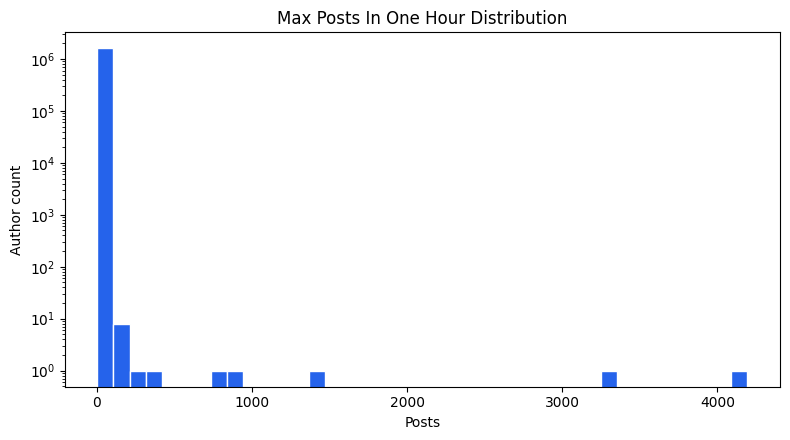

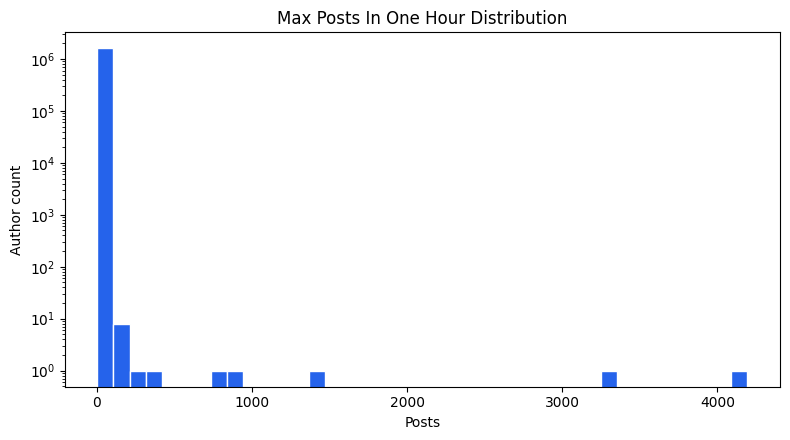

In [77]:
fig = plot_hourly_distribution(result["author_scores"])
fig

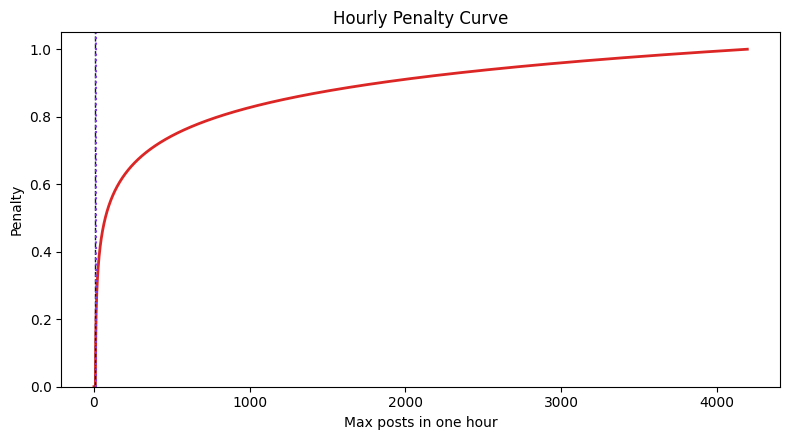

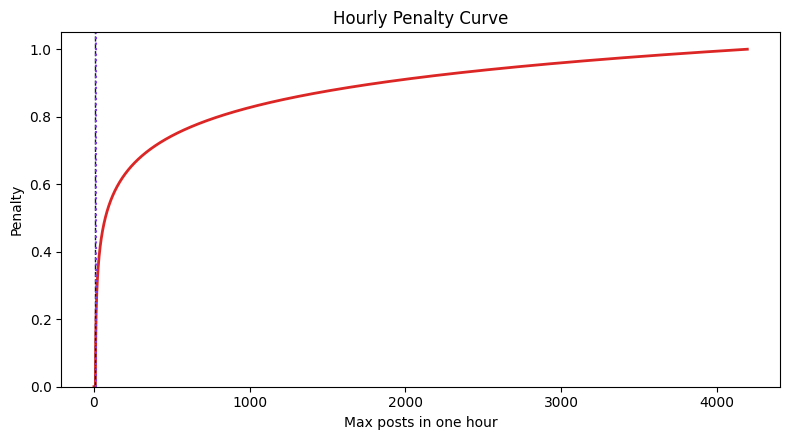

In [78]:
fig = plot_hourly_penalty_curve(result["author_scores"], RUN_CONFIG)
fig

In [79]:
tables["language_diversity_authors"].head(20)

,author_hash,total_posts,active_days,active_hours,language_nunique,theme_nunique,sentiment_std,posts_per_day,posts_per_active_hour,max_posts_one_hour,mean_interpost_sec,median_interpost_sec,p10_interpost_sec,std_interpost_sec,interval_cv,same_text_repeat_ratio,same_text_repeat_max,multi_author_repeat_ratio,activity_posts_per_day_risk,activity_posts_per_hour_risk,author_hard_hourly_flag,activity_hourly_penalty_risk,activity_risk,timing_mean_gap_risk,timing_median_gap_risk,timing_p10_gap_risk,timing_cv_risk,timing_risk,repetition_same_text_ratio_risk,repetition_same_text_max_risk,repetition_multi_author_risk,repetition_risk,diversity_language_risk,diversity_theme_risk,diversity_sentiment_risk,diversity_risk,metadata_risk,author_score
1361677,da39a3ee5e6b4b0d3255bfef95601890afd80709,14962,7,13,66,15,0.396275,2137.428571,1150.923077,1460,57.79226,2.0,0.0,3762.439554,65.102828,0.009023,5,0.019182,1.0,1.0,1,0.87298,0.930139,0.999905,0.999998,1.0,0.0,0.749985,0.009023,1.0,0.019182,0.261339,1.0,1.0,0.555933,0.86678,0.0,0.930139
65973,0a92fab3230134cca6eadd9898325b9b2ae67998,35147,7,13,62,15,0.442052,5021.0,2703.615385,4194,24.601064,1.0,0.0,2454.886906,99.787834,0.090819,35,0.056875,1.0,1.0,1,1.0,1.0,0.999961,1.0,1.0,0.0,0.749994,0.090819,1.0,0.056875,0.30284,0.935484,1.0,0.620155,0.86024,0.0,1.0
363999,3a52ce780950d4d969792a2559cd519d7ee8c727,2321,7,13,40,15,0.397589,331.571429,178.538462,248,372.684914,13.0,2.0,9551.562116,25.629055,0.010771,8,0.020681,1.0,1.0,1,0.656708,0.81119,0.999381,0.99998,0.999997,0.0,0.749901,0.010771,1.0,0.020681,0.262538,0.580645,1.0,0.557777,0.699591,0.0,0.81119
972413,9bed5104004c5fe4e3e46673da174472bff1360a,23599,7,13,34,15,0.398166,3371.285714,1815.307692,3252,36.639969,1.0,0.0,2995.895731,81.765781,0.002754,9,0.000212,1.0,1.0,1,0.969421,0.983181,0.999941,1.0,1.0,0.0,0.749991,0.002754,1.0,0.000212,0.250922,0.483871,1.0,0.558586,0.661124,0.0,0.983181
626229,64542dbabb81dfd446e0cf4f319567c72ee57c7b,973,7,13,27,15,0.41035,139.0,74.846154,101,889.504115,30.5,5.0,14751.166046,16.583584,0.00925,3,0.021583,1.0,1.0,1,0.542229,0.748226,0.998521,0.999951,0.999992,0.0,0.749763,0.00925,1.0,0.021583,0.262487,0.370968,1.0,0.57568,0.621091,0.0,0.749763
1236979,c63ae6dd4fc9f9dda66970e827d13f7c73fe841c,598,7,13,25,15,0.396418,85.428571,46.0,65,1448.055276,51.0,6.0,18811.087178,12.990586,0.023411,4,0.0301,1.0,1.0,1,0.482699,0.715484,0.997592,0.999917,0.99999,0.0,0.749615,0.023411,1.0,0.0301,0.270569,0.33871,1.0,0.556134,0.602324,0.0,0.749615
685452,6dcd4ce23d88e2ee9568ba546c007c63d9131c1b,582,7,13,24,15,0.389955,83.142857,44.769231,60,1487.917384,55.0,8.0,19062.899011,12.811799,0.010309,2,0.024055,1.0,1.0,1,0.471484,0.709316,0.997525,0.99991,0.999987,0.0,0.749602,0.010309,1.0,0.024055,0.263918,0.322581,1.0,0.547068,0.593153,0.0,0.749602
1313684,d27937f914ebe99ee315f04449678eccfb658191,886,7,13,23,15,0.42209,126.571429,68.153846,92,976.946893,30.0,5.0,15452.02811,15.816651,0.023702,4,0.037246,1.0,1.0,1,0.529884,0.741436,0.998376,0.999952,0.999992,0.0,0.749741,0.023702,1.0,0.037246,0.273871,0.306452,1.0,0.59215,0.600226,0.0,0.749741
551699,58668e7669fd564d99db5d581fcdb6a5618440b5,669,7,13,21,15,0.405787,95.571429,51.461538,66,1294.25,45.0,7.7,17782.993785,13.739999,0.00299,2,0.025411,1.0,1.0,1,0.484821,0.716652,0.997848,0.999927,0.999987,0.0,0.749654,0.00299,1.0,0.025411,0.262332,0.274194,1.0,0.569278,0.580461,0.0,0.749654
1047586,a7ee38bb7be4fc44198cb2685d9601dcf2b9f569,409,7,13,21,15,0.415754,58.428571,31.461538,49,2119.02451,77.0,9.0,22731.751376,10.72746,0.00489,2,0.017115,1.0,1.0,1,0.442351,0.693293,0.996475,0.999874,0.999985,0.0,0.749434,0.00489,1.0,0.017115,0.259169,0.274194,1.0,0.583261,0.584656,0.0,0.749434


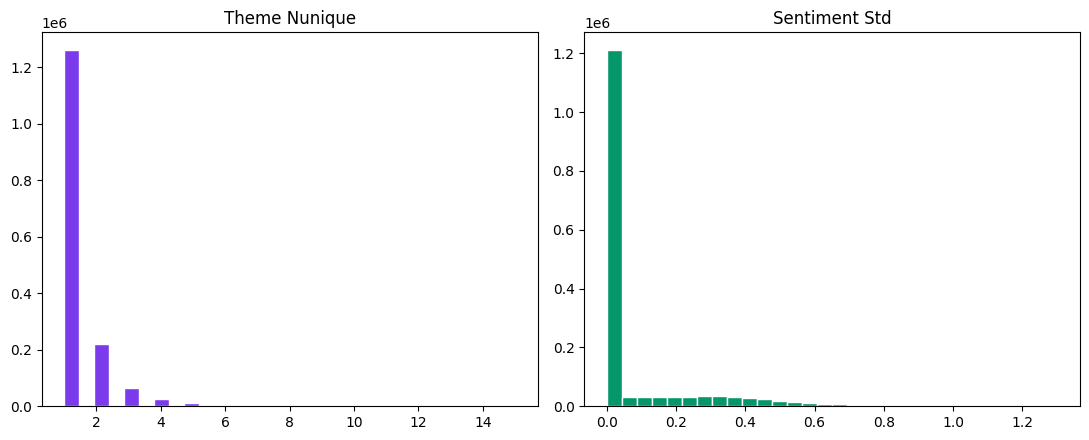

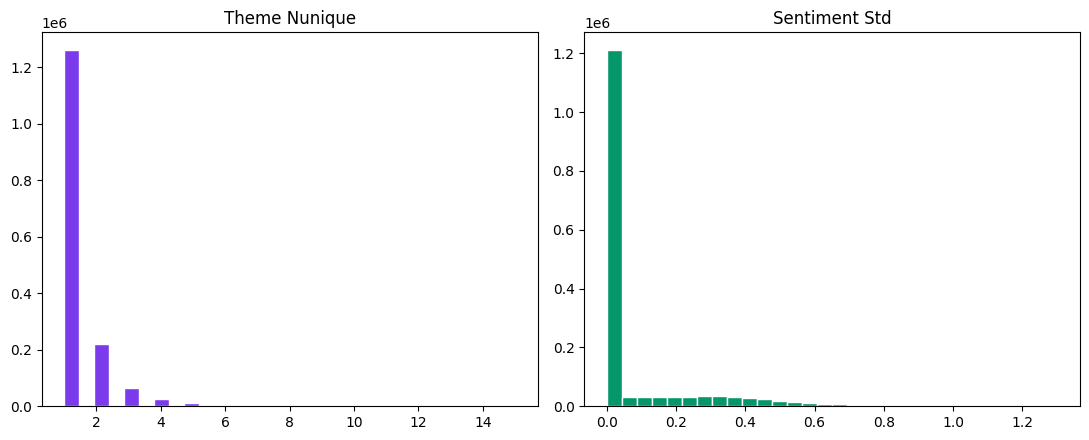

In [80]:
fig = plot_sentiment_theme_distributions(result["author_scores"])
fig

## Repeat / Spam / Hard Bot Kontrolleri

In [81]:
pd.set_option("display.max_columns", 100)
tables["hard_bot_examples"].head(20)

,message_id,normalized_text,roberta_score,author_hash,author_type,date,keyword_count,text_length_chars,token_count,unique_token_count,max_token_frequency,max_token_ratio,repeated_token_count_over_2,hashtag_count,hashtag_density_chars,hashtag_density_tokens,is_long_text_flag,time_window_bucket,same_text_repeat_count,same_text_unique_author_count,same_text_time_window_count,author_score,author_hard_hourly_flag,spam_pattern_flag,hard_bot_cluster_flag,same_text_repeat_risk,same_text_multi_author_risk,same_text_time_window_risk,same_text_repeat_component,spam_pattern_component,hashtag_count_risk,hashtag_density_chars_risk,hashtag_density_tokens_risk,hashtag_spam_component,token_frequency_risk,token_ratio_risk,token_repeat_cluster_risk,token_repetition_component,long_text_component,keyword_signal_component,hard_same_text_repeat_flag,message_score,behavioral_score,behavioral_confidence_weight,roberta_confidence_weight,behavioral_effective_weight,roberta_effective_weight,final_score_before_rules,final_score
0,73,[ Audioboom uses Javascript n nPlease enable i...,0.917126,NaN,anonymous,2024-11-19T19:00:00+00:00,26,462,79,55,7,0.088608,3,0,0.0,0.0,1,5773,7,0,3,NaN,0,1,0,0.001686,0.000000,0.001169,0.000992,1.0,0.0,0.0,0.0,0.0,0.018373,0.088608,0.050847,0.056473,0.775947,0.022807,1,1.0,1.0,1.0,0.756780,0.725693,0.274307,0.977267,1.0
1,137,"Comments that are uncivil, racist, misogynisti...",0.961483,100d6bf8ae69fe55412deb0b842151aca38f37e2,identified,2024-11-19T19:00:00+00:00,24,778,121,82,5,0.041322,11,0,0.0,0.0,1,5773,39,1,7,0.900375,1,1,0,0.009393,0.001623,0.002727,0.005340,1.0,0.0,0.0,0.0,0.0,0.013123,0.041322,0.186441,0.060476,0.845992,0.021053,1,1.0,1.0,1.0,0.881494,0.616336,0.383664,0.985223,1.0
2,351,Higher monthly payments loom for many student ...,0.502401,994a95a45bee0cb7a8b6f21fc0dc87b7aefca1c0,identified,2024-11-19T19:00:01+00:00,12,60,9,9,1,0.111111,0,0,0.0,0.0,1,5773,6,6,6,0.803001,0,1,1,0.001445,0.009740,0.002337,0.004527,1.0,0.0,0.0,0.0,0.0,0.002625,0.111111,0.000000,0.050919,0.438924,0.010526,1,1.0,1.0,1.0,0.200018,0.960832,0.039168,0.980510,1.0
3,440,Same here.,0.307534,NaN,anonymous,2024-11-19T19:00:01+00:00,0,10,2,2,1,0.500000,0,0,0.0,0.0,0,5773,20,5,5,NaN,0,1,1,0.004817,0.008117,0.001948,0.005398,1.0,0.0,0.0,0.0,0.0,0.002625,0.500000,0.000000,0.225919,0.000000,0.000000,1,1.0,1.0,1.0,0.318538,0.938535,0.061465,0.957437,1.0
4,511,*cough*,0.350682,685f6224ba91b2a8a0e917623fea2dfb9885831f,identified,2024-11-19T19:00:02+00:00,1,7,1,1,1,1.000000,0,0,0.0,0.0,0,5773,5,4,4,0.117000,0,1,1,0.001204,0.006494,0.001558,0.003126,1.0,0.0,0.0,0.0,0.0,0.002625,1.000000,0.000000,0.450919,0.000000,0.000877,0,1.0,1.0,1.0,0.271347,0.948564,0.051436,0.966602,1.0
5,539,Le previsioni meteo di domani: https://buff.ly...,0.500000,63ffb98ddb0c38dd204e57efb24e984128ba5b08,identified,2024-11-19T19:00:02+00:00,4,54,9,9,1,0.111111,0,0,0.0,0.0,1,5773,6,2,2,1.000000,0,1,0,0.001445,0.003247,0.000779,0.001942,1.0,0.0,0.0,0.0,0.0,0.002625,0.111111,0.000000,0.050919,0.411429,0.003509,1,1.0,1.0,1.0,0.200000,1.000000,0.000000,1.000000,1.0
6,552,*cough*,0.350682,NaN,anonymous,2024-11-19T19:00:02+00:00,1,7,1,1,1,1.000000,0,0,0.0,0.0,0,5773,5,4,4,NaN,0,1,1,0.001204,0.006494,0.001558,0.003126,1.0,0.0,0.0,0.0,0.0,0.002625,1.000000,0.000000,0.450919,0.000000,0.000877,0,1.0,1.0,1.0,0.271347,0.948564,0.051436,0.966602,1.0
7,555,General Motors recalls more than 539K vehicles...,0.404299,c6140dbadb823d73be21d0fbe75d200fe314ce3f,identified,2024-11-19T19:00:02+00:00,9,80,15,15,1,0.066667,0,0,0.0,0.0,1,5773,6,6,6,0.789077,0,1,1,0.001445,0.009740,0.002337,0.004527,1.0,0.0,0.0,0.0,0.0,0.002625,0.066667,0.000000,0.030919,0.502557,0.007895,1,1.0,1.0,1.0,0.229308,0.956176,0.043824,0.973894,1.0
8,570,Si,0.500000,aefb4c9c60e975a10d918f355ee566bcf1faeaf0,identified,2024-11-19T19:00:02+00:00,1,2,1,1,1,1.000000,0,0,0.0,0.0,0,5773,40,38,8,0.117000,0,1,1,0.009634,0.061688,0.003116,0.026549,1.0,0.0,0.0,0.0,0.0,0.002625,1.000000,0.000000,0.450919,0.000000,0.000877,1,1.0,1.0,1.0,0.2000

In [82]:
tables["rapid_fire_examples"].head(20)

,author_hash,total_posts,active_days,active_hours,language_nunique,theme_nunique,sentiment_std,posts_per_day,posts_per_active_hour,max_posts_one_hour,mean_interpost_sec,median_interpost_sec,p10_interpost_sec,std_interpost_sec,interval_cv,same_text_repeat_ratio,same_text_repeat_max,multi_author_repeat_ratio,activity_posts_per_day_risk,activity_posts_per_hour_risk,author_hard_hourly_flag,activity_hourly_penalty_risk,activity_risk,timing_mean_gap_risk,timing_median_gap_risk,timing_p10_gap_risk,timing_cv_risk,timing_risk,repetition_same_text_ratio_risk,repetition_same_text_max_risk,repetition_multi_author_risk,repetition_risk,diversity_language_risk,diversity_theme_risk,diversity_sentiment_risk,diversity_risk,metadata_risk,author_score
36,0001bcbeea0c137f80d59049b2a4c9e5a095af7a,2,1,1,1,2,0.438406,2.0,2.0,2,0.0,0.0,0.0,<NA>,inf,0.0,1,0.0,0.333333,0.5,0,0.0,0.191667,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.25,0.61504,0.259512,0.0,0.75
686,001ac44854d9d30145171c9e038367e7965f44a6,2,1,1,1,2,0.339411,2.0,2.0,2,0.0,0.0,0.0,<NA>,inf,0.0,1,0.0,0.333333,0.5,0,0.0,0.191667,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.25,0.47616,0.217848,0.0,0.75
1254,0032e0a085966a29e7d106d796078b2ad52bf189,4,1,1,1,1,0.221115,4.0,4.0,4,400.0,0.0,0.0,692.820323,1.732051,0.0,1,0.0,1.0,1.0,0,0.0,0.45,0.999336,1.0,1.0,0.269501,0.817276,0.0,0.0,0.0,0.0,0.0,0.0,0.310202,0.09306,0.0,0.817276
1258,0033005602995f6d9067110cc09af6a3fd6e6901,2,1,1,1,1,0.374767,2.0,2.0,2,0.0,0.0,0.0,<NA>,inf,0.0,1,0.0,0.333333,0.5,0,0.0,0.191667,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.52576,0.157728,0.0,0.75
1866,004cc287cb5315eba6b152f5f802d78213e2d5a8,2,1,1,1,2,0.579828,2.0,2.0,2,0.0,0.0,0.0,<NA>,inf,0.0,1,0.0,0.333333,0.5,0,0.0,0.191667,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.25,0.81344,0.319032,0.0,0.75
2576,00682997e19a5fbc7f9429a43c0f08e43aaba211,2,1,1,1,1,0.289914,2.0,2.0,2,0.0,0.0,0.0,<NA>,inf,0.0,1,0.0,0.333333,0.5,0,0.0,0.191667,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.40672,0.122016,0.0,0.75
2809,00724861d32b7afb45b89645a3b3649000f2a95e,3,1,1,1,2,0.08544,3.0,3.0,3,0.0,0.0,0.0,0.0,inf,0.0,1,0.0,0.666667,1.0,0,0.0,0.383333,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.25,0.119864,0.110959,0.0,0.75
2972,0079ee1de3e79307c5433eb3e4434da5d85e74e4,8,1,1,1,1,0.008345,8.0,8.0,8,0.571429,0.0,0.0,0.786796,1.376893,0.0,1,0.0,1.0,1.0,0,0.0,0.45,1.0,1.0,1.0,0.420162,0.855041,0.0,0.0,0.0,0.0,0.0,0.0,0.011708,0.003512,0.0,0.855041
3280,0086e839b723d54d92b727263ebaeb6c14d7bfc3,6,1,1,1,1,0.148324,6.0,6.0,6,0.0,0.0,0.0,0.0,inf,0.666667,4,0.833333,1.0,1.0,0,0.0,0.45,1.0,1.0,1.0,0.0,0.75,0.666667,1.0,0.833333,0.825,0.0,0.0,0.208084,0.062425,0.0,0.825
3370,008af2e6c7d2b1e35c61470d104b1c308df72475,2,1,1,1,1,0.374767,2.0,2.0,2,0.0,0.0,0.0,<NA>,inf,0.0,1,0.0,0.333333,0.5,0,0.0,0.191667,1.0,1.0,1.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.52576,0.157728,0.0,0.75


In [83]:
tables["score_bands"]

,band,rows,share
0,0.00-0.40,3816556,0.762692
1,0.40-0.60,446800,0.089287
2,0.60-0.70,144643,0.028905
3,0.70-0.85,182826,0.036536
4,0.85-<1.0,105604,0.021104
5,1.0,307632,0.061476


## Keyword ve Spam Ornekleri

In [84]:
tables["keyword_validation"]

,is_heavy_message,avg_keyword_count,rows
0,False,12.659646,4831895
1,True,10.683265,172166


In [85]:
tables["hashtag_spam_examples"][[
    "normalized_text",
    "hashtag_count",
    "hashtag_spam_component",
    "message_score",
    "final_score",
]].head(20)

,normalized_text,hashtag_count,hashtag_spam_component,message_score,final_score
0,#USA #PR #Caribbean #NH #VT #MASS #CONN #NY #N...,42,0.657955,0.697831,0.288011
1,#bist100 #thyao #halkaarz #cwene #asuzu #ahgaz...,36,0.606509,0.698374,0.698374
2,#BlueSky #fyp #trending #nsfw #skyhub #ass #eg...,34,0.599309,1.000000,0.717329
3,#Bitcoin #BTC #Ethereum #ETH #Solana #SOL #Car...,35,0.589068,0.699453,0.310389
4,https://x.com/borsaistsefiri/status/1858843046...,39,0.579234,0.720681,0.370876
5,#paris #malemodel #instagay #hoscos #gaymuscle...,31,0.549774,0.730316,0.181329
6,.\n.\n.\n#maroc #france #españa #rabat #casabl...,28,0.545588,0.682845,0.105216
7,#cristo19766 #cristo19766fan❤️ #sardaigne #sar...,29,0.538866,0.716989,0.309949
8,#cosmetics #beauty #makeup #skincare #makeupar...,28,0.535000,1.000000,0.735771
9,#psychedelic #psychedelicart #psytrance #tripp...,28,0.532534,0.712220,0.454932


In [86]:
tables["token_spam_examples"][[
    "normalized_text",
    "max_token_frequency",
    "max_token_ratio",
    "token_repetition_component",
    "message_score",
    "final_score",
]].head(20)

,normalized_text,max_token_frequency,max_token_ratio,token_repetition_component,message_score,final_score
0,cancel cancel cancel cancel cancel cancel canc...,100,1.000000,0.545253,0.831745,0.954078
1,"No worries fam, I got you. Just copy paste:\n\...",100,0.917431,0.508097,0.840054,0.876799
2,$DOG $DOG $DOG $DOG $DOG $DOG $DOG $DOG $DOG $...,48,1.000000,0.497484,1.000000,1.000000
3,$DOG $DOG $DOG $DOG $DOG $DOG $DOG $DOG $DOG $...,48,1.000000,0.497484,1.000000,1.000000
4,$BONE $BONE $BONE $BONE\n$BONE $BONE $BONE $BO...,40,1.000000,0.490135,1.000000,0.976110
5,adjacent adjacent adjacent adjacent adjacent a...,31,1.000000,0.481868,0.705228,0.978125
6,$PEPE $PEPE $PEPE $PEPE $PEPE $PEPE $PEPE $PEP...,19,1.000000,0.470844,0.030452,0.808698
7,#RonaldoFenere #RonaldoFenere #RonaldoFenere #...,18,1.000000,0.469925,0.700522,0.700522
8,Ao3&gt;&gt;&gt;&gt;&gt;&gt;&gt;&gt;&gt;&gt;&gt...,39,0.951220,0.467265,0.031305,0.031305
9,#BringBackJJMaybank#BringBackJJMaybank#BringBa...,8,1.000000,0.460739,0.035573,0.061686


## Skor Ciktilari

In [87]:
scored_preview = result.get("scored_preview")

if scored_preview is None:
    if "scored_df" in result:
        scored_preview = result["scored_df"].head(20).copy()
    else:
        scored_path = Path(RUN_CONFIG["paths"]["scored_messages_parquet"])
        scored_preview = pd.read_parquet(scored_path).head(20)
    result["scored_preview"] = scored_preview

scored_preview[[
    "author_hash",
    "author_type",
    "normalized_text",
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "behavioral_effective_weight",
    "roberta_effective_weight",
    "final_score_before_rules",
    "final_score",
    "hard_bot_cluster_flag",
    "hard_same_text_repeat_flag",
]].head(20)


,author_hash,author_type,normalized_text,author_score,message_score,behavioral_score,roberta_score,behavioral_effective_weight,roberta_effective_weight,final_score_before_rules,final_score,hard_bot_cluster_flag,hard_same_text_repeat_flag
0,0bc0d8e84df6cbb7a7ae9230f1419f5c8cbeed02,identified,"In a world of limits, ECOMMBX stands with thos...",0.000000,0.696189,0.696189,0.035183,0.093399,0.906601,0.096920,0.096920,0,0
1,NaN,anonymous,No te la vas a follar,NaN,0.003315,0.003315,0.500000,1.000000,0.000000,0.003315,0.003315,0,0
2,58a54891d3e82f616dca839494063a2b275df4ee,identified,Today’s local sports headlines:\n• Tigers go 3...,0.000000,0.012510,0.003753,0.024881,0.565298,0.434702,0.012937,0.012937,0,0
3,40d35b3def5890ab3b94cbe8a84b4897615839ed,identified,Corbin Carroll\n\n#JAGAHCAuctions1119\nLast sa...,0.748816,0.016213,0.529035,0.168963,0.199104,0.800896,0.240655,0.240655,0,0
4,b1f59aaca3aa386b308d5805d6e4e8932498379e,identified,人気アニメ「サザエさん」シリーズが、放送55周年に合わせて2つのギネス世界記録を更新した。\...,0.787492,0.012132,0.554884,0.500000,1.000000,0.000000,0.554884,0.554884,0,0
5,7f9df19c30ad833c1ed02a5bd4658e870b734cbc,identified,Road safety for #KS3 students involves real-wo...,0.000000,0.698915,0.698915,0.929940,0.134750,0.865250,0.898809,0.898809,0,0
6,6a6ff5d0cc5762981788c07497d7d6b570ce377b,identified,Franz Schubert (31 janvier 1797 - 19 novembre ...,0.000000,0.722488,0.722488,0.500000,1.000000,0.000000,0.722488,0.722488,0,0
7,0df87234f65998f2aa05fe6f06ad5da6bd2327a1,identified,England\n\nAfter the Nations League match betw...,0.763984,0.702110,0.745422,0.019372,0.101026,0.898974,0.092722,0.092722,0,0
8,3ee26b37d26834e315784f3afac348a9b92850dd,identified,Sorry babe,0.000000,0.009258,0.002777,0.500000,1.000000,0.000000,0.002777,0.002777,0,0
9,5e1ee936400307061313ca56067eb61f11698b96,identified,José Mourinho: Antigo jogador não esquece “gue...,0.000000,0.013585,0.004076,0.500000,1.000000,0.000000,0.004076,0.004076,0,0


## Final Score Dagilimi

Bu hucreler `scored_messages.parquet` icinden dagilimi ve band ayrisimini gosterir. Readiness check bu hucrelerden once calismis olmali.


In [88]:
score_dist_columns = [
    "final_score",
    "behavioral_score",
    "roberta_score",
    "behavioral_effective_weight",
    "roberta_effective_weight",
    "final_score_before_rules",
    "hard_bot_cluster_flag",
    "author_hard_hourly_flag",
]

validate_scored_outputs(RUN_CONFIG, manifest)
score_dist_path = Path(RUN_CONFIG["paths"]["scored_messages_parquet"])
score_dist = pd.read_parquet(score_dist_path, columns=score_dist_columns)

score_dist.describe(include="all")


,final_score,behavioral_score,roberta_score,behavioral_effective_weight,roberta_effective_weight,final_score_before_rules,hard_bot_cluster_flag,author_hard_hourly_flag
count,5.004061e+06,5.004061e+06,5.004061e+06,5.004061e+06,5.004061e+06,5.004061e+06,5.004061e+06,5.004061e+06
mean,2.237004e-01,2.887015e-01,3.095193e-01,7.056662e-01,2.943338e-01,2.045288e-01,1.520025e-02,4.031106e-02
std,3.095108e-01,3.405217e-01,2.203642e-01,3.222865e-01,3.222865e-01,2.786330e-01,1.223487e-01,1.966878e-01
min,3.725869e-05,3.725869e-05,1.231792e-04,0.000000e+00,0.000000e+00,3.725869e-05,0.000000e+00,0.000000e+00
25%,2.439384e-02,8.259870e-03,1.093675e-01,4.832506e-01,0.000000e+00,2.439182e-02,0.000000e+00,0.000000e+00
50%,3.828099e-02,1.499385e-02,2.870820e-01,8.596225e-01,1.403775e-01,3.825853e-02,0.000000e+00,0.000000e+00
75%,3.581572e-01,5.995596e-01,5.000000e-01,1.000000e+00,5.167494e-01,3.234506e-01,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,9.999152e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


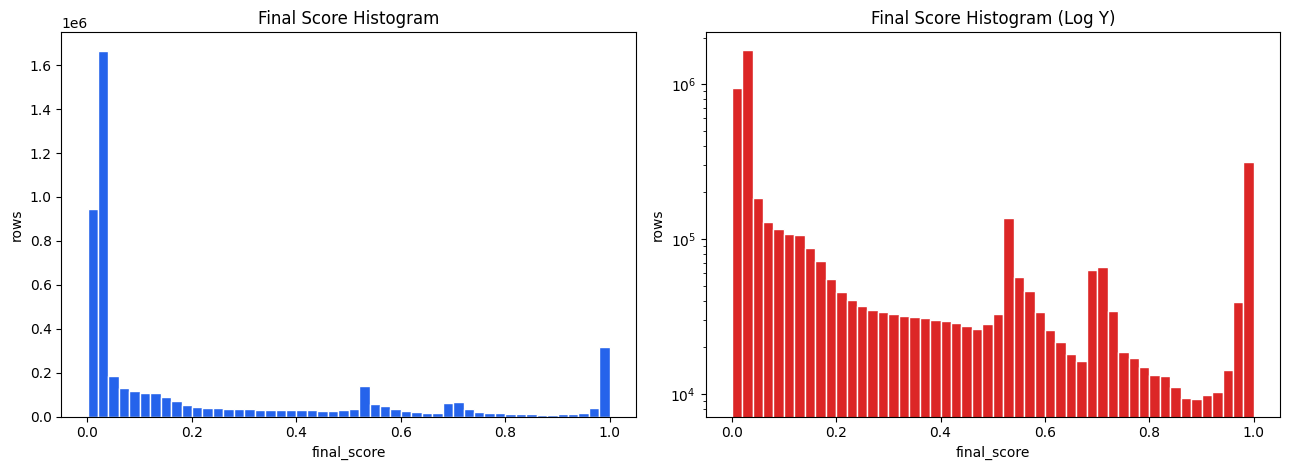

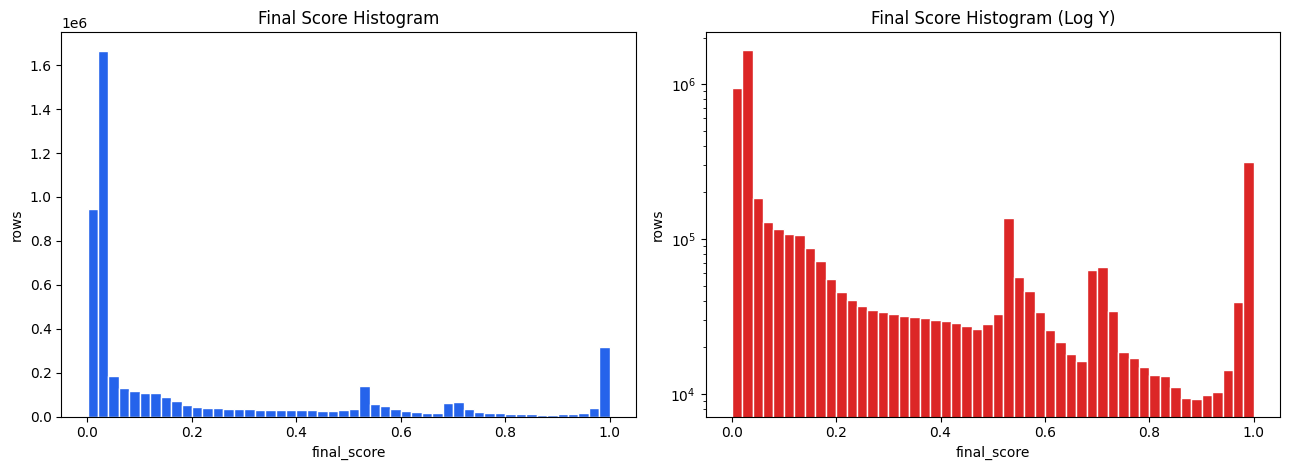

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(score_dist["final_score"], bins=50, color="#2563eb", edgecolor="white")
axes[0].set_title("Final Score Histogram")
axes[0].set_xlabel("final_score")
axes[0].set_ylabel("rows")

axes[1].hist(score_dist["final_score"], bins=50, color="#dc2626", edgecolor="white")
axes[1].set_title("Final Score Histogram (Log Y)")
axes[1].set_xlabel("final_score")
axes[1].set_ylabel("rows")
axes[1].set_yscale("log")

fig.tight_layout()
fig


In [90]:
score_bands_full = pd.cut(
    score_dist["final_score"],
    bins=[-0.001, 0.4, 0.6, 0.7, 0.85, 0.999999, 1.000001],
    labels=["0.00-0.40", "0.40-0.60", "0.60-0.70", "0.70-0.85", "0.85-<1.0", "1.0"],
    include_lowest=True,
)

score_band_summary = score_bands_full.value_counts(sort=False).rename_axis("band").reset_index(name="rows")
score_band_summary["share"] = score_band_summary["rows"] / max(len(score_dist), 1)
score_band_summary


,band,rows,share
0,0.00-0.40,3816556,0.762692
1,0.40-0.60,446800,0.089287
2,0.60-0.70,144643,0.028905
3,0.70-0.85,182826,0.036536
4,0.85-<1.0,105604,0.021104
5,1.0,307632,0.061476


## Tek Mesaj Inference Scaffold

In [ ]:
single_message = prepare_single_message_input(
    message_text="hi guys good morning how are you today",
    language="en",
    author_hash=None,
    english_keywords="example, test, inference",
    primary_theme="unknown_theme",
)

score_single_message(single_message, result, RUN_CONFIG)

,author_type,message_score,author_score,behavioral_score,roberta_score,behavioral_confidence_weight,roberta_confidence_weight,behavioral_effective_weight,roberta_effective_weight,final_score_before_rules,final_score,same_text_repeat_component,spam_pattern_component,hashtag_spam_component,token_repetition_component,long_text_component,keyword_signal_component,author_hard_hourly_flag,hard_bot_cluster_flag,hard_same_text_repeat_flag
0,anonymous,0.008009,NaN,0.008009,0.723164,0.974577,0.359367,0.921351,0.078649,0.064255,0.064255,0.0,0.0,0.0,0.057169,0.280844,0.002632,0,0,0


## Dashboard: Score Distribution And Driver Analysis

Bu blok mevcut `scored_messages.parquet`, `fusion_batch_store.sqlite` ve `fusion_author_scores.parquet` dosyalarini kullanir. Full pipeline'i yeniden calistirmaz. Dashboard analizi, genel skor dagilimi ile birlikte dil, platform ve `author_type` kirilimlarini gosterir.

In [96]:
import sqlite3
import pyarrow.dataset as ds
import matplotlib.patheffects as pe

DASHBOARD_SCORE_COLUMNS = [
    "message_id",
    "author_type",
    "same_text_repeat_count",
    "same_text_unique_author_count",
    "same_text_time_window_count",
    "hashtag_count",
    "max_token_frequency",
    "max_token_ratio",
    "hard_bot_cluster_flag",
    "hard_same_text_repeat_flag",
    "author_hard_hourly_flag",
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "behavioral_confidence_weight",
    "roberta_confidence_weight",
    "behavioral_effective_weight",
    "roberta_effective_weight",
    "final_score_before_rules",
    "final_score",
]

DASHBOARD_AUTHOR_COLUMNS = [
    "author_hash",
    "activity_risk",
    "timing_risk",
    "repetition_risk",
    "diversity_risk",
    "metadata_risk",
    "max_posts_one_hour",
    "median_interpost_sec",
    "language_nunique",
    "theme_nunique",
    "sentiment_std",
    "author_score",
]

SCORE_BAND_EDGES = [-0.001, 0.4, 0.6, 0.7, 0.85, 0.999999, 1.000001]
SCORE_BAND_LABELS = ["0.00-0.40", "0.40-0.60", "0.60-0.70", "0.70-0.85", "0.85-<1.0", "1.0"]


def build_score_bands(series: pd.Series) -> pd.Categorical:
    return pd.cut(series, bins=SCORE_BAND_EDGES, labels=SCORE_BAND_LABELS, include_lowest=True)


def collapse_top_categories(series: pd.Series, top_n: int = 10, other_label: str = "Other") -> pd.Series:
    base = series.fillna("unknown").astype("string")
    top_values = base.value_counts().head(top_n).index
    collapsed = base.where(base.isin(top_values), other_label)
    return collapsed.astype("category")


def plot_matrix_heatmap(data: pd.DataFrame, title: str, cmap: str = "YlOrRd", value_fmt: str = ".2f"):
    fig, ax = plt.subplots(figsize=(1.5 * max(len(data.columns), 4), 0.8 * max(len(data.index), 4)))
    data_values = data.to_numpy(dtype=float)
    cmap_obj = plt.get_cmap(cmap)
    image = ax.imshow(data_values, aspect="auto", cmap=cmap_obj)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    ax.set_title(title)
    norm = image.norm
    for row_idx in range(len(data.index)):
        for col_idx in range(len(data.columns)):
            value = data_values[row_idx, col_idx]
            if np.isnan(value):
                label_text = "na"
                text_color = "black"
                stroke_color = "white"
            else:
                rgba = cmap_obj(norm(value))
                brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                label_text = format(value, value_fmt)
                text_color = "black" if brightness > 0.6 else "white"
                stroke_color = "white" if text_color == "black" else "black"
            ax.text(
                col_idx,
                row_idx,
                label_text,
                ha="center",
                va="center",
                color=text_color,
                fontsize=8,
                path_effects=[pe.withStroke(linewidth=2.0, foreground=stroke_color)],
            )
    fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02)
    fig.tight_layout()
    return fig


def plot_normalized_stack(ax, source_df: pd.DataFrame, group_col: str, top_n: int, title: str):
    grouped = source_df[[group_col, "score_band"]].copy()
    grouped[group_col] = collapse_top_categories(grouped[group_col], top_n=top_n)
    share = pd.crosstab(grouped[group_col], grouped["score_band"], normalize="index")
    share = share.reindex(columns=SCORE_BAND_LABELS, fill_value=0.0)
    share.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel("share")
    ax.legend(title="score_band", bbox_to_anchor=(1.02, 1), loc="upper left")
    return share


validate_scored_outputs(RUN_CONFIG, manifest)

score_path = Path(RUN_CONFIG["paths"]["scored_messages_parquet"])
author_path = Path(RUN_CONFIG["paths"]["author_scores_parquet"])
sqlite_path = Path(RUN_CONFIG["paths"]["batch_sqlite_db"])

score_df = pd.read_parquet(score_path, columns=DASHBOARD_SCORE_COLUMNS)
score_df["message_id"] = pd.to_numeric(score_df["message_id"], errors="coerce").astype("int64")
score_df["author_type"] = score_df["author_type"].fillna("unknown").astype("category")

for column in score_df.columns:
    if column in {"message_id", "author_type"}:
        continue
    if pd.api.types.is_float_dtype(score_df[column]):
        score_df[column] = pd.to_numeric(score_df[column], errors="coerce").astype("float32")
    elif pd.api.types.is_integer_dtype(score_df[column]):
        score_df[column] = pd.to_numeric(score_df[column], errors="coerce", downcast="integer")

with sqlite3.connect(sqlite_path) as conn:
    context_df = pd.read_sql_query(
        """
        SELECT
            message_id,
            COALESCE(NULLIF(language, ''), 'unknown') AS language,
            COALESCE(NULLIF(registered_domain, ''), 'unknown') AS registered_domain,
            date,
            keyword_count,
            text_length_chars,
            repeated_token_count_over_2,
            is_long_text_flag
        FROM cleaned_messages
        """,
        conn,
    )

context_df["message_id"] = pd.to_numeric(context_df["message_id"], errors="coerce").astype("int64")
for column in ["language", "registered_domain"]:
    context_df[column] = context_df[column].fillna("unknown").astype("category")
context_df["date"] = pd.to_datetime(context_df["date"], errors="coerce", utc=True)
context_df["date_day"] = context_df["date"].dt.floor("D")
for column in ["keyword_count", "text_length_chars", "repeated_token_count_over_2", "is_long_text_flag"]:
    context_df[column] = pd.to_numeric(context_df[column], errors="coerce", downcast="integer")

dashboard_df = score_df.merge(context_df, on="message_id", how="left", copy=False)
dashboard_df["language_top"] = collapse_top_categories(dashboard_df["language"], top_n=10)
dashboard_df["platform_top"] = collapse_top_categories(dashboard_df["registered_domain"], top_n=10)
dashboard_df["score_band"] = build_score_bands(dashboard_df["final_score"])
dashboard_df["hard_rule_any"] = (
    dashboard_df[["hard_bot_cluster_flag", "hard_same_text_repeat_flag", "author_hard_hourly_flag"]]
    .fillna(0)
    .max(axis=1)
    .astype("int8")
)

author_df = pd.read_parquet(author_path, columns=DASHBOARD_AUTHOR_COLUMNS)
for column in author_df.columns:
    if column == "author_hash":
        continue
    if pd.api.types.is_float_dtype(author_df[column]):
        author_df[column] = pd.to_numeric(author_df[column], errors="coerce").astype("float32")
    elif pd.api.types.is_integer_dtype(author_df[column]):
        author_df[column] = pd.to_numeric(author_df[column], errors="coerce", downcast="integer")

message_component_candidates = [
    "same_text_repeat_component",
    "spam_pattern_component",
    "hashtag_spam_component",
    "token_repetition_component",
    "long_text_component",
    "keyword_signal_component",
]
dashboard_message_component_columns = [col for col in message_component_candidates if col in dashboard_df.columns]
author_component_candidates = ["activity_risk", "timing_risk", "repetition_risk", "diversity_risk", "metadata_risk"]
dashboard_author_component_columns = [col for col in author_component_candidates if col in author_df.columns]

high_risk_dataset = ds.dataset(score_path, format="parquet")
high_risk_columns = [
    "message_id",
    "normalized_text",
    "author_type",
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "final_score",
    "hard_bot_cluster_flag",
    "hard_same_text_repeat_flag",
    "author_hard_hourly_flag",
    "same_text_repeat_count",
    "same_text_unique_author_count",
    "same_text_time_window_count",
    "hashtag_count",
    "max_token_frequency",
    "max_token_ratio",
]
top_high_risk_ids = (
    dashboard_df.loc[dashboard_df["final_score"].ge(0.85)]
    .sort_values(
        ["final_score", "hard_bot_cluster_flag", "hard_same_text_repeat_flag", "author_hard_hourly_flag"],
        ascending=[False, False, False, False],
    )["message_id"]
    .head(20)
    .tolist()
)
if top_high_risk_ids:
    high_risk_table = high_risk_dataset.to_table(
        columns=high_risk_columns,
        filter=ds.field("message_id").isin(top_high_risk_ids),
    ).to_pandas()
    high_risk_table["message_id"] = pd.to_numeric(high_risk_table["message_id"], errors="coerce").astype("int64")
    high_risk_table = high_risk_table.merge(
        context_df[["message_id", "language", "registered_domain", "keyword_count"]],
        on="message_id",
        how="left",
    )
    high_risk_table = high_risk_table.sort_values(
        ["final_score", "hard_bot_cluster_flag", "hard_same_text_repeat_flag", "author_hard_hourly_flag"],
        ascending=[False, False, False, False],
    )
else:
    high_risk_table = pd.DataFrame(columns=high_risk_columns + ["language", "registered_domain", "keyword_count"])

print({
    "dashboard_rows": int(len(dashboard_df)),
    "author_rows": int(len(author_df)),
    "high_risk_rows": int(len(high_risk_table)),
    "message_component_columns": dashboard_message_component_columns,
    "author_component_columns": dashboard_author_component_columns,
})

/var/folders/lb/_sf4xmsn3v38zhlnqd793tn00000gn/T/ipykernel_25690/761049673.py:127: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  dashboard_df = score_df.merge(context_df, on="message_id", how="left", copy=False)


{'dashboard_rows': 5004061, 'author_rows': 1597837, 'high_risk_rows': 20, 'message_component_columns': [], 'author_component_columns': ['activity_risk', 'timing_risk', 'repetition_risk', 'diversity_risk', 'metadata_risk']}


In [97]:
dashboard_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "final_score_mean",
            "final_score_median",
            "final_score_p90",
            "final_score_p99",
            "share_final_score_ge_0_70",
            "share_final_score_ge_0_85",
            "share_final_score_eq_1_0",
            "share_any_hard_rule",
            "avg_behavioral_effective_weight",
            "avg_roberta_effective_weight",
        ],
        "value": [
            len(dashboard_df),
            dashboard_df["final_score"].mean(),
            dashboard_df["final_score"].median(),
            dashboard_df["final_score"].quantile(0.90),
            dashboard_df["final_score"].quantile(0.99),
            dashboard_df["final_score"].ge(0.70).mean(),
            dashboard_df["final_score"].ge(0.85).mean(),
            dashboard_df["final_score"].eq(1.0).mean(),
            dashboard_df["hard_rule_any"].mean(),
            dashboard_df["behavioral_effective_weight"].mean(),
            dashboard_df["roberta_effective_weight"].mean(),
        ],
    }
)
dashboard_summary

,metric,value
0,rows,5.004061e+06
1,final_score_mean,2.237005e-01
2,final_score_median,3.828099e-02
3,final_score_p90,7.367800e-01
4,final_score_p99,1.000000e+00
5,share_final_score_ge_0_70,1.191157e-01
6,share_final_score_ge_0_85,8.258013e-02
7,share_final_score_eq_1_0,6.147647e-02
8,share_any_hard_rule,5.810061e-02
9,avg_behavioral_effective_weight,7.056662e-01


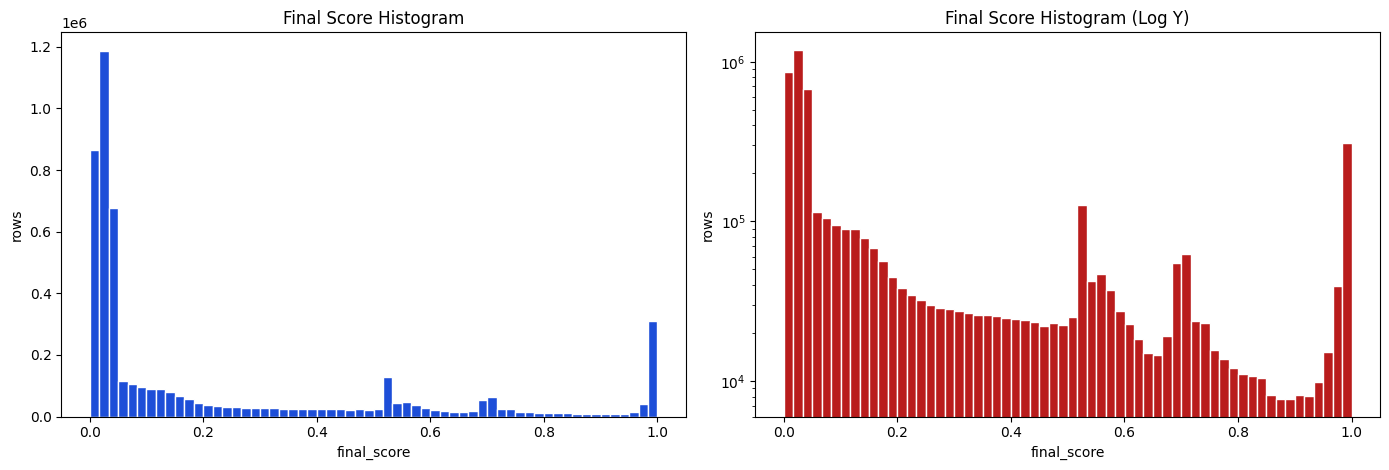

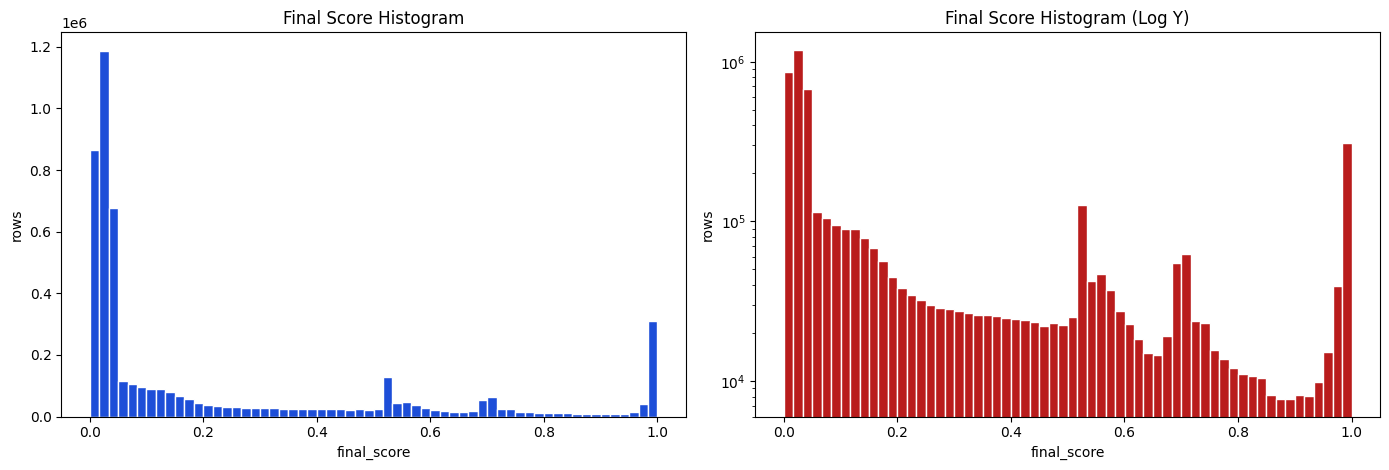

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist(dashboard_df["final_score"].dropna(), bins=60, color="#1d4ed8", edgecolor="white")
axes[0].set_title("Final Score Histogram")
axes[0].set_xlabel("final_score")
axes[0].set_ylabel("rows")

axes[1].hist(dashboard_df["final_score"].dropna(), bins=60, color="#b91c1c", edgecolor="white")
axes[1].set_title("Final Score Histogram (Log Y)")
axes[1].set_xlabel("final_score")
axes[1].set_ylabel("rows")
axes[1].set_yscale("log")

fig.tight_layout()
fig

/var/folders/lb/_sf4xmsn3v38zhlnqd793tn00000gn/T/ipykernel_25690/1191598306.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=score_view_columns, showfliers=False)


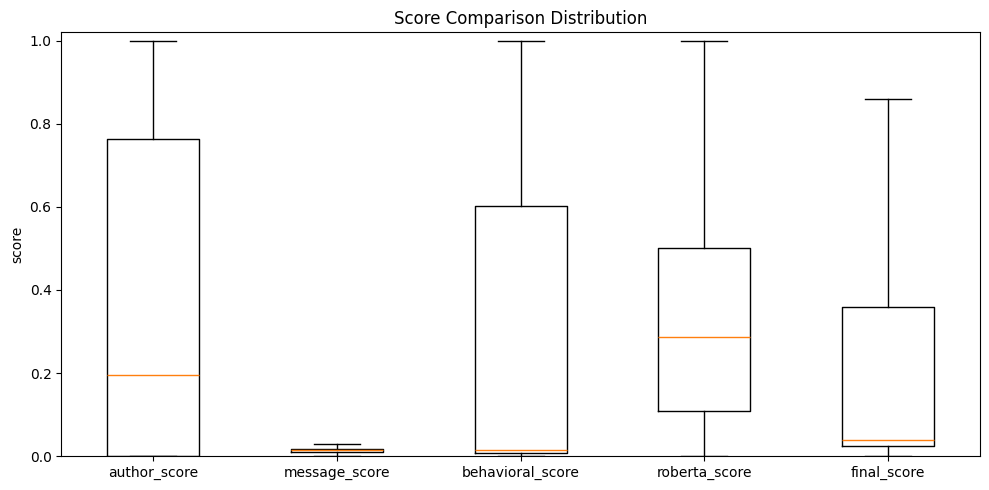

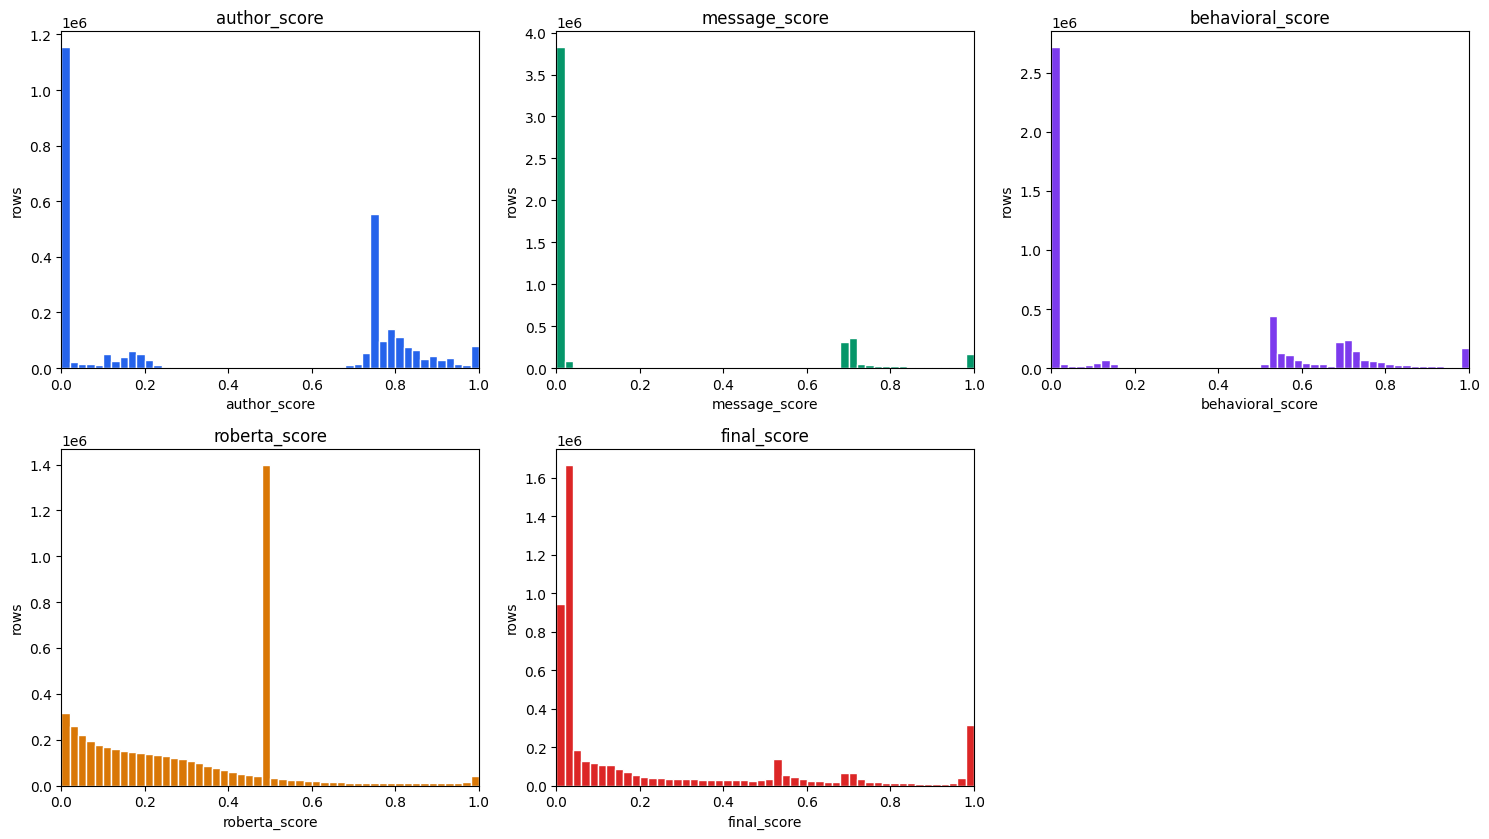

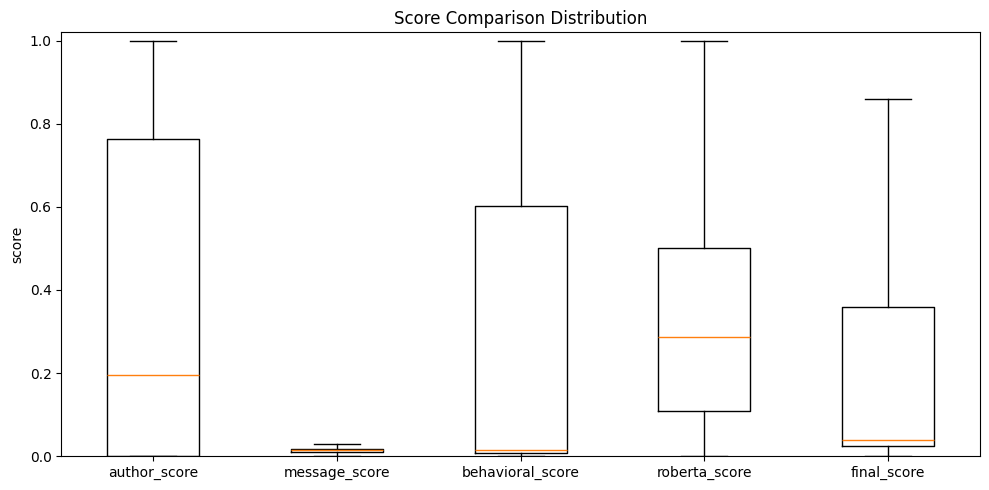

In [99]:
score_view_columns = ["author_score", "message_score", "behavioral_score", "roberta_score", "final_score"]
score_colors = ["#2563eb", "#059669", "#7c3aed", "#d97706", "#dc2626"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.flatten()
for idx, column in enumerate(score_view_columns):
    axes[idx].hist(dashboard_df[column].dropna(), bins=50, color=score_colors[idx], edgecolor="white")
    axes[idx].set_title(column)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_xlabel(column)
    axes[idx].set_ylabel("rows")
axes[-1].axis("off")
fig.tight_layout()
fig

fig, ax = plt.subplots(figsize=(10, 5))
box_data = [dashboard_df[column].dropna().sample(min(150000, dashboard_df[column].notna().sum()), random_state=42) for column in score_view_columns]
ax.boxplot(box_data, labels=score_view_columns, showfliers=False)
ax.set_ylim(0, 1.02)
ax.set_title("Score Comparison Distribution")
ax.set_ylabel("score")
fig.tight_layout()
fig

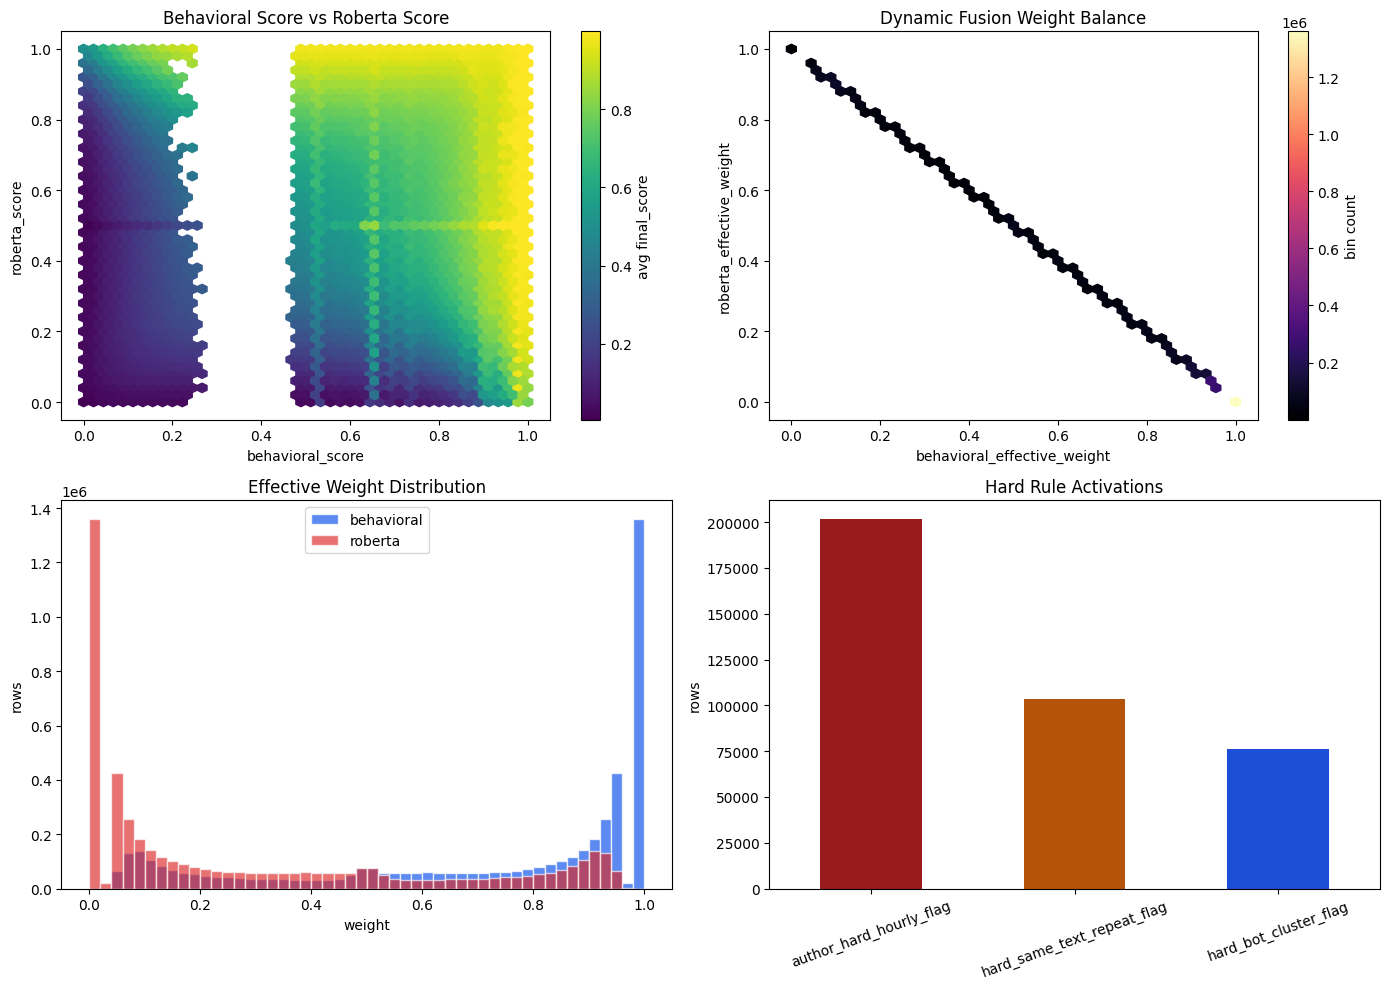

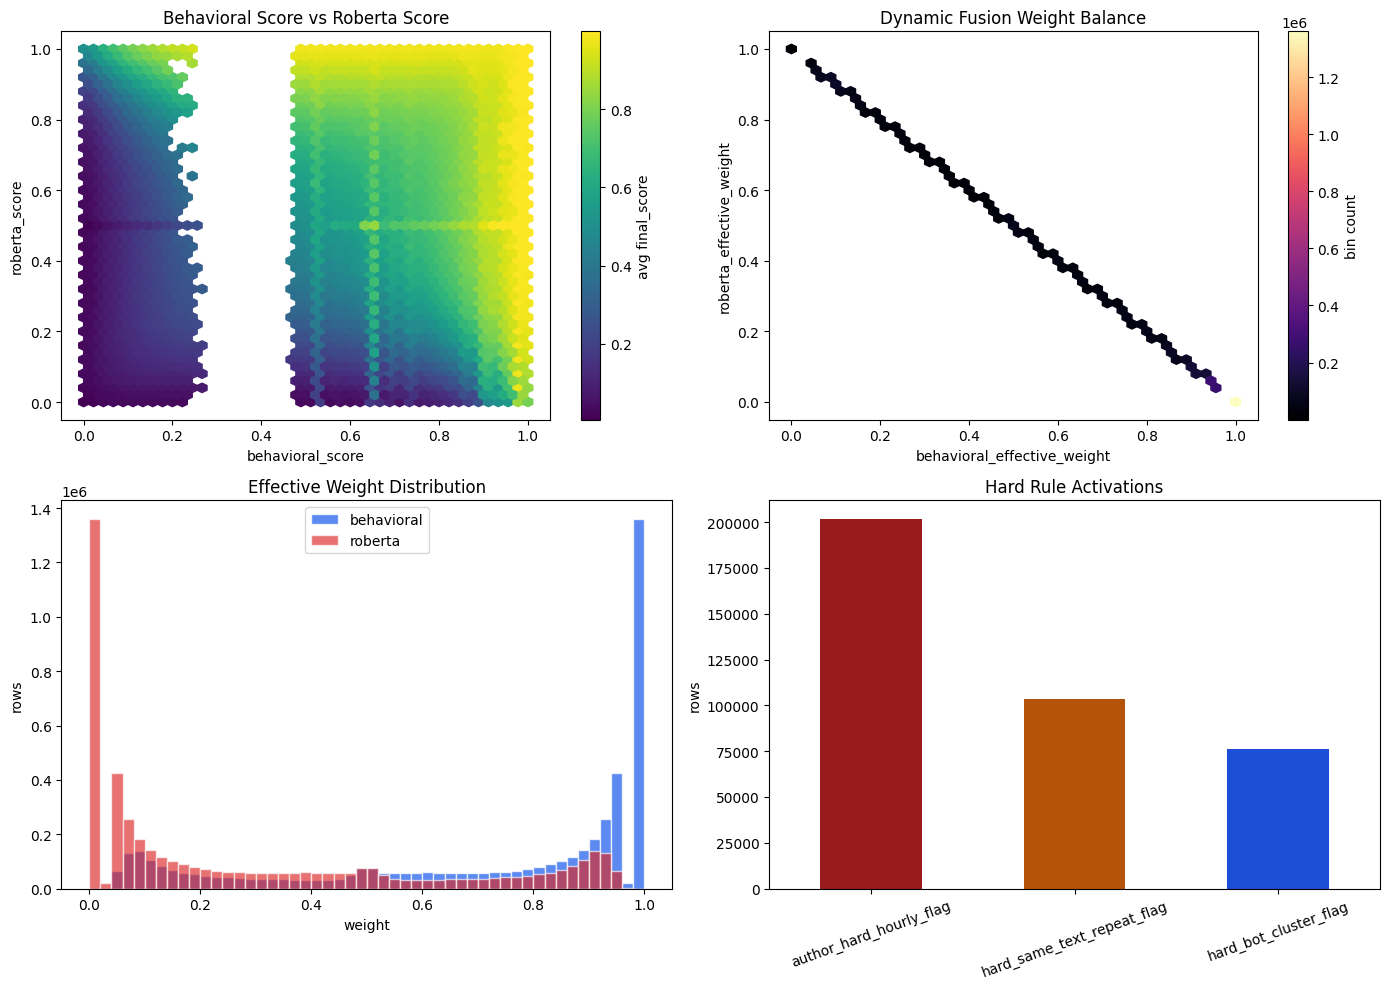

In [101]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hb = axes[0, 0].hexbin(
    dashboard_df["behavioral_score"],
    dashboard_df["roberta_score"],
    C=dashboard_df["final_score"],
    reduce_C_function=np.mean,
    gridsize=45,
    cmap="viridis",
    mincnt=1,
)
axes[0, 0].set_title("Behavioral Score vs Roberta Score")
axes[0, 0].set_xlabel("behavioral_score")
axes[0, 0].set_ylabel("roberta_score")
fig.colorbar(hb, ax=axes[0, 0], label="avg final_score")

hb2 = axes[0, 1].hexbin(
    dashboard_df["behavioral_effective_weight"],
    dashboard_df["roberta_effective_weight"],
    gridsize=45,
    cmap="magma",
    mincnt=1,
)
axes[0, 1].set_title("Dynamic Fusion Weight Balance")
axes[0, 1].set_xlabel("behavioral_effective_weight")
axes[0, 1].set_ylabel("roberta_effective_weight")
fig.colorbar(hb2, ax=axes[0, 1], label="bin count")

axes[1, 0].hist(dashboard_df["behavioral_effective_weight"].dropna(), bins=50, alpha=0.75, color="#2563eb", edgecolor="white", label="behavioral")
axes[1, 0].hist(dashboard_df["roberta_effective_weight"].dropna(), bins=50, alpha=0.65, color="#dc2626", edgecolor="white", label="roberta")
axes[1, 0].set_title("Effective Weight Distribution")
axes[1, 0].set_xlabel("weight")
axes[1, 0].set_ylabel("rows")
axes[1, 0].legend()

hard_rule_counts = pd.Series(
    {
        "hard_bot_cluster_flag": int(dashboard_df["hard_bot_cluster_flag"].fillna(0).sum()),
        "hard_same_text_repeat_flag": int(dashboard_df["hard_same_text_repeat_flag"].fillna(0).sum()),
        "author_hard_hourly_flag": int(dashboard_df["author_hard_hourly_flag"].fillna(0).sum()),
    }
)
hard_rule_counts.sort_values(ascending=False).plot(kind="bar", ax=axes[1, 1], color=["#991b1b", "#b45309", "#1d4ed8"])
axes[1, 1].set_title("Hard Rule Activations")
axes[1, 1].set_ylabel("rows")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig

In [ ]:
message_driver_columns = [
    "same_text_repeat_count",
    "same_text_unique_author_count",
    "same_text_time_window_count",
    "hashtag_count",
    "max_token_frequency",
    "max_token_ratio",
    "keyword_count",
    "repeated_token_count_over_2",
    "text_length_chars",
]
message_driver_titles = {
    "same_text_repeat_count": "Same Text Repeat Count",
    "same_text_unique_author_count": "Unique Authors Using Same Text",
    "same_text_time_window_count": "Same Text Time Window Count",
    "hashtag_count": "Hashtag Count",
    "max_token_frequency": "Max Token Frequency",
    "max_token_ratio": "Max Token Ratio",
    "keyword_count": "Keyword Count",
    "repeated_token_count_over_2": "Repeated Token Count >= 3",
    "text_length_chars": "Text Length Chars",
}

available_driver_columns = [column for column in message_driver_columns if column in dashboard_df.columns]
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()
for idx, column in enumerate(available_driver_columns):
    axes[idx].hist(dashboard_df[column].dropna(), bins=50, color="#0f766e", edgecolor="white")
    axes[idx].set_title(message_driver_titles[column])
    axes[idx].set_ylabel("rows")
    axes[idx].set_yscale("log")
for idx in range(len(available_driver_columns), len(axes)):
    axes[idx].axis("off")
fig.tight_layout()
fig

if dashboard_message_component_columns:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
    axes = axes.flatten()
    for idx, column in enumerate(dashboard_message_component_columns):
        axes[idx].hist(dashboard_df[column].dropna(), bins=50, color="#7c3aed", edgecolor="white")
        axes[idx].set_title(column)
        axes[idx].set_xlim(0, 1)
        axes[idx].set_ylabel("rows")
    for idx in range(len(dashboard_message_component_columns), len(axes)):
        axes[idx].axis("off")
    fig.tight_layout()
    fig
else:
    print("message component columns were not persisted in scored_messages.parquet; raw driver distributions are shown instead.")

In [ ]:
author_view_columns = dashboard_author_component_columns or [
    "max_posts_one_hour",
    "median_interpost_sec",
    "language_nunique",
    "theme_nunique",
    "sentiment_std",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.flatten()
for idx, column in enumerate(author_view_columns):
    axes[idx].hist(author_df[column].dropna(), bins=50, color="#2563eb", edgecolor="white")
    axes[idx].set_title(column)
    axes[idx].set_ylabel("authors")
    if column.endswith("_risk") or column == "author_score":
        axes[idx].set_xlim(0, 1)
    if column == "median_interpost_sec":
        axes[idx].set_xscale("log")
for idx in range(len(author_view_columns), len(axes)):
    axes[idx].axis("off")
fig.tight_layout()
fig

In [ ]:
band_metric_columns = [
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "behavioral_effective_weight",
    "roberta_effective_weight",
    "same_text_repeat_count",
    "same_text_unique_author_count",
    "same_text_time_window_count",
    "hashtag_count",
    "max_token_frequency",
    "max_token_ratio",
    "keyword_count",
]

band_summary = (
    dashboard_df.groupby("score_band", observed=False)[band_metric_columns]
    .mean()
    .reindex(SCORE_BAND_LABELS)
)
band_summary

heatmap_metrics = [
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "behavioral_effective_weight",
    "roberta_effective_weight",
    "same_text_repeat_count",
    "same_text_unique_author_count",
    "same_text_time_window_count",
    "hashtag_count",
    "keyword_count",
]
plot_matrix_heatmap(band_summary[heatmap_metrics], "Band-Level Mean Metric Heatmap")

high_band = band_summary.loc[["0.00-0.40", "0.70-0.85", "0.85-<1.0", "1.0"], [
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "behavioral_effective_weight",
    "roberta_effective_weight",
]].T
high_band.plot(kind="bar", figsize=(12, 5), color=["#94a3b8", "#60a5fa", "#f59e0b", "#dc2626"])
plt.title("Metric Means Across Key Score Bands")
plt.ylabel("mean")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
language_summary = (
    dashboard_df.groupby("language_top", observed=False)
    .agg(rows=("final_score", "size"), mean_final_score=("final_score", "mean"), high_risk_share=("final_score", lambda s: s.ge(0.85).mean()))
    .sort_values("rows", ascending=False)
)
platform_summary = (
    dashboard_df.groupby("platform_top", observed=False)
    .agg(rows=("final_score", "size"), mean_final_score=("final_score", "mean"), high_risk_share=("final_score", lambda s: s.ge(0.85).mean()))
    .sort_values("rows", ascending=False)
)
author_type_summary = (
    dashboard_df.groupby("author_type", observed=False)
    .agg(rows=("final_score", "size"), mean_final_score=("final_score", "mean"), high_risk_share=("final_score", lambda s: s.ge(0.85).mean()))
    .sort_values("rows", ascending=False)
)

print("Language summary")
display(language_summary.head(10))
print("Platform summary")
display(platform_summary.head(10))
print("Author type summary")
display(author_type_summary)

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

language_summary.head(10)["mean_final_score"].sort_values().plot(kind="barh", ax=axes[0, 0], color="#2563eb")
axes[0, 0].set_title("Mean Final Score By Language")
axes[0, 0].set_xlabel("mean_final_score")
plot_normalized_stack(axes[0, 1], dashboard_df, "language", top_n=10, title="Score Band Composition By Language")

platform_summary.head(10)["mean_final_score"].sort_values().plot(kind="barh", ax=axes[1, 0], color="#059669")
axes[1, 0].set_title("Mean Final Score By Platform")
axes[1, 0].set_xlabel("mean_final_score")
plot_normalized_stack(axes[1, 1], dashboard_df, "registered_domain", top_n=10, title="Score Band Composition By Platform")

author_type_summary["mean_final_score"].sort_values().plot(kind="barh", ax=axes[2, 0], color="#7c3aed")
axes[2, 0].set_title("Mean Final Score By Author Type")
axes[2, 0].set_xlabel("mean_final_score")
author_type_band_share = pd.crosstab(dashboard_df["author_type"], dashboard_df["score_band"], normalize="index").reindex(columns=SCORE_BAND_LABELS, fill_value=0.0)
author_type_band_share.plot(kind="bar", stacked=True, ax=axes[2, 1], colormap="plasma")
axes[2, 1].set_title("Score Band Composition By Author Type")
axes[2, 1].set_xlabel("author_type")
axes[2, 1].set_ylabel("share")
axes[2, 1].legend(title="score_band", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig

fig, ax = plt.subplots(figsize=(10, 5))
author_type_values = author_type_summary.index.astype(str).tolist()
author_type_box_data = [
    dashboard_df.loc[dashboard_df["author_type"].astype("string") == value, "final_score"].dropna().sample(
        min(120000, int(dashboard_df.loc[dashboard_df["author_type"].astype("string") == value, "final_score"].notna().sum())),
        random_state=42,
    )
    for value in author_type_values
]
ax.boxplot(author_type_box_data, labels=author_type_values, showfliers=False)
ax.set_title("Final Score Distribution By Author Type")
ax.set_ylabel("final_score")
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig

In [ ]:
high_risk_examples = high_risk_table[[
    "normalized_text",
    "language",
    "registered_domain",
    "author_type",
    "author_score",
    "message_score",
    "behavioral_score",
    "roberta_score",
    "final_score",
    "hard_bot_cluster_flag",
    "hard_same_text_repeat_flag",
    "author_hard_hourly_flag",
    "same_text_repeat_count",
    "same_text_unique_author_count",
    "same_text_time_window_count",
    "hashtag_count",
    "max_token_frequency",
    "max_token_ratio",
    "keyword_count",
]].head(20)
high_risk_examples

## Model Genel Ozet

Bu blok, mevcut `fusion_scored_messages.parquet` uzerinden modelin kac mesaji bot riski tasiyan grup olarak isaretledigini, kacini dusuk riskte biraktigini ve genel skor dagilimini ozetler.

In [104]:
MODEL_BOT_THRESHOLD = 0.51
MODEL_HIGH_RISK_THRESHOLD = 0.85

model_summary_df = dashboard_df.copy()
model_summary_df["is_bot_pred"] = model_summary_df["final_score"].ge(MODEL_BOT_THRESHOLD)
model_summary_df["is_high_risk_pred"] = model_summary_df["final_score"].ge(MODEL_HIGH_RISK_THRESHOLD)
model_summary_df["is_hard_rule_pred"] = model_summary_df[[
    "hard_bot_cluster_flag",
    "hard_same_text_repeat_flag",
    "author_hard_hourly_flag",
]].fillna(0).max(axis=1).eq(1)

bot_count = int(model_summary_df["is_bot_pred"].sum())
non_bot_count = int((~model_summary_df["is_bot_pred"]).sum())
high_risk_count = int(model_summary_df["is_high_risk_pred"].sum())
hard_rule_count = int(model_summary_df["is_hard_rule_pred"].sum())

general_model_summary = pd.DataFrame(
    {
        "metric": [
            "total_rows",
            f"bot_pred_rows_ge_{MODEL_BOT_THRESHOLD:.2f}",
            f"non_bot_rows_lt_{MODEL_BOT_THRESHOLD:.2f}",
            f"high_risk_rows_ge_{MODEL_HIGH_RISK_THRESHOLD:.2f}",
            "hard_rule_rows",
            "bot_pred_share",
            "non_bot_share",
            "high_risk_share",
            "hard_rule_share",
            "final_score_mean",
            "final_score_median",
            "final_score_std",
            "author_score_mean",
            "message_score_mean",
            "behavioral_score_mean",
            "roberta_score_mean",
        ],
        "value": [
            len(model_summary_df),
            bot_count,
            non_bot_count,
            high_risk_count,
            hard_rule_count,
            bot_count / max(len(model_summary_df), 1),
            non_bot_count / max(len(model_summary_df), 1),
            high_risk_count / max(len(model_summary_df), 1),
            hard_rule_count / max(len(model_summary_df), 1),
            model_summary_df["final_score"].mean(),
            model_summary_df["final_score"].median(),
            model_summary_df["final_score"].std(),
            model_summary_df["author_score"].mean(),
            model_summary_df["message_score"].mean(),
            model_summary_df["behavioral_score"].mean(),
            model_summary_df["roberta_score"].mean(),
        ],
    }
)
count_metrics = {
    "total_rows",
    f"bot_pred_rows_ge_{MODEL_BOT_THRESHOLD:.2f}",
    f"non_bot_rows_lt_{MODEL_BOT_THRESHOLD:.2f}",
    f"high_risk_rows_ge_{MODEL_HIGH_RISK_THRESHOLD:.2f}",
    "hard_rule_rows",
}
general_model_summary["value"] = general_model_summary.apply(
    lambda row: f"{int(row['value']):,}" if row["metric"] in count_metrics else f"{float(row['value']):.6f}",
    axis=1,
)
general_model_summary


,metric,value
0,total_rows,"5,004,061"
1,bot_pred_rows_ge_0.51,"1,032,674"
2,non_bot_rows_lt_0.51,"3,971,387"
3,high_risk_rows_ge_0.85,"413,236"
4,hard_rule_rows,"290,739"
5,bot_pred_share,0.206367
6,non_bot_share,0.793633
7,high_risk_share,0.082580
8,hard_rule_share,0.058101
9,final_score_mean,0.223700


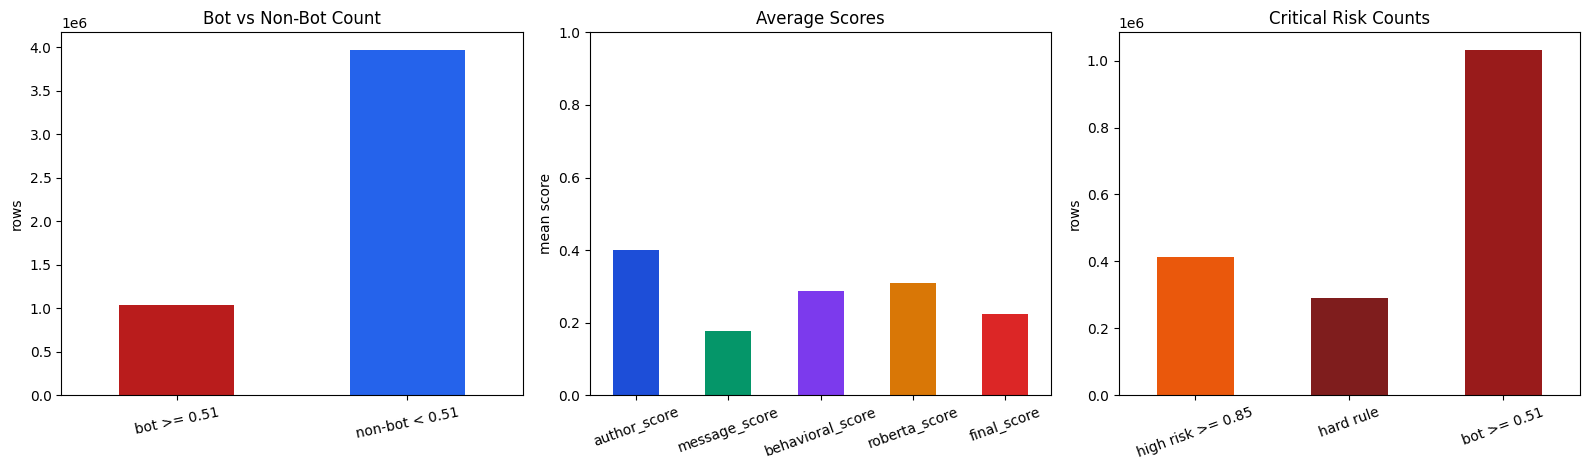

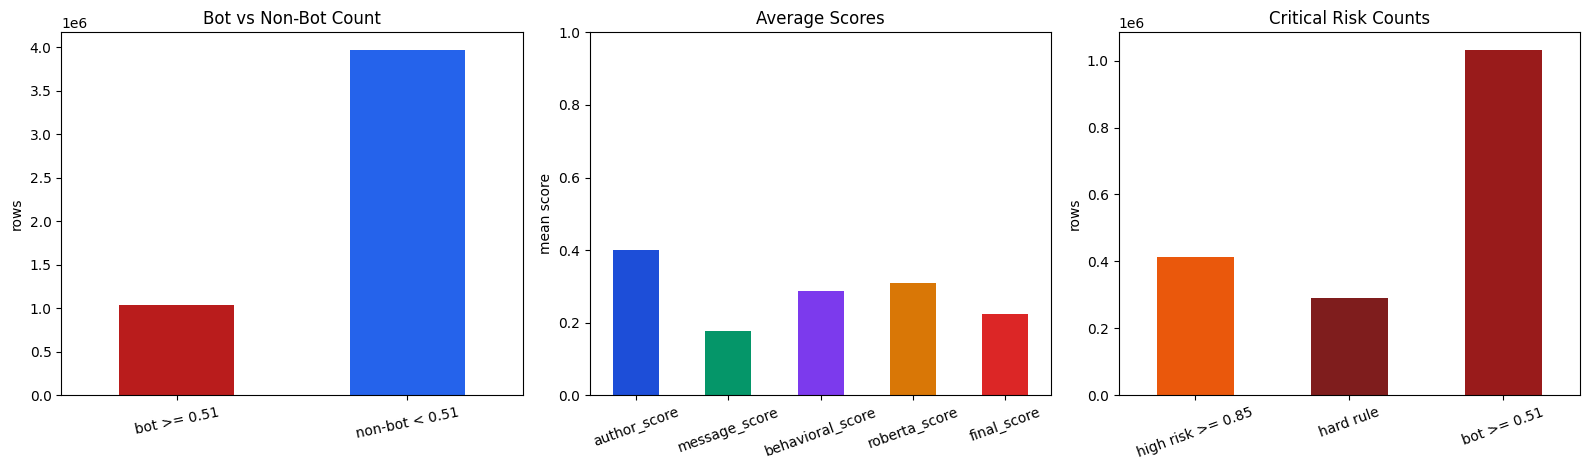

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

pd.Series(
    {
        f"bot >= {MODEL_BOT_THRESHOLD:.2f}": bot_count,
        f"non-bot < {MODEL_BOT_THRESHOLD:.2f}": non_bot_count,
    }
).plot(kind="bar", ax=axes[0], color=["#b91c1c", "#2563eb"])
axes[0].set_title("Bot vs Non-Bot Count")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=12)

pd.Series(
    {
        "author_score": model_summary_df["author_score"].mean(),
        "message_score": model_summary_df["message_score"].mean(),
        "behavioral_score": model_summary_df["behavioral_score"].mean(),
        "roberta_score": model_summary_df["roberta_score"].mean(),
        "final_score": model_summary_df["final_score"].mean(),
    }
).plot(kind="bar", ax=axes[1], color=["#1d4ed8", "#059669", "#7c3aed", "#d97706", "#dc2626"])
axes[1].set_title("Average Scores")
axes[1].set_ylabel("mean score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

pd.Series(
    {
        f"high risk >= {MODEL_HIGH_RISK_THRESHOLD:.2f}": high_risk_count,
        "hard rule": hard_rule_count,
        f"bot >= {MODEL_BOT_THRESHOLD:.2f}": bot_count,
    }
).plot(kind="bar", ax=axes[2], color=["#ea580c", "#7f1d1d", "#991b1b"])
axes[2].set_title("Critical Risk Counts")
axes[2].set_ylabel("rows")
axes[2].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig

## Manipulation Map

This block focuses on where manipulation risk concentrates across language, platform, and time.


In [106]:
MAP_BOT_THRESHOLD = 0.70
MAP_HIGH_RISK_THRESHOLD = 0.85

map_df = dashboard_df.copy()

if "date_day" not in map_df.columns:
    if "date" in map_df.columns:
        map_df["date"] = pd.to_datetime(map_df["date"], errors="coerce", utc=True)
        map_df["date_day"] = map_df["date"].dt.floor("D")
    else:
        with sqlite3.connect(sqlite_path) as conn:
            map_dates_df = pd.read_sql_query(
                """
                SELECT
                    message_id,
                    date
                FROM cleaned_messages
                """,
                conn,
            )
        map_dates_df["message_id"] = pd.to_numeric(map_dates_df["message_id"], errors="coerce").astype("int64")
        map_dates_df["date"] = pd.to_datetime(map_dates_df["date"], errors="coerce", utc=True)
        map_dates_df["date_day"] = map_dates_df["date"].dt.floor("D")
        map_df = map_df.merge(map_dates_df[["message_id", "date_day"]], on="message_id", how="left", copy=False)
else:
    map_df["date_day"] = pd.to_datetime(map_df["date_day"], errors="coerce", utc=True)

map_df["weekday_name"] = pd.Categorical(
    map_df["date_day"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
map_df["is_bot_pred"] = map_df["final_score"].ge(MAP_BOT_THRESHOLD)
map_df["is_high_risk_pred"] = map_df["final_score"].ge(MAP_HIGH_RISK_THRESHOLD)

language_map_summary = (
    map_df.groupby("language_top", observed=False)
    .agg(
        rows=("final_score", "size"),
        mean_final_score=("final_score", "mean"),
        bot_share=("is_bot_pred", "mean"),
        high_risk_share=("is_high_risk_pred", "mean"),
    )
    .sort_values("rows", ascending=False)
)

platform_map_summary = (
    map_df.groupby("platform_top", observed=False)
    .agg(
        rows=("final_score", "size"),
        mean_final_score=("final_score", "mean"),
        bot_share=("is_bot_pred", "mean"),
        high_risk_share=("is_high_risk_pred", "mean"),
    )
    .sort_values("rows", ascending=False)
)

daily_map_summary = (
    map_df.dropna(subset=["date_day"])
    .groupby("date_day", observed=False)
    .agg(
        rows=("final_score", "size"),
        mean_final_score=("final_score", "mean"),
        bot_share=("is_bot_pred", "mean"),
        high_risk_share=("is_high_risk_pred", "mean"),
    )
    .reset_index()
    .sort_values("date_day")
)

weekday_map_summary = (
    map_df.dropna(subset=["weekday_name"])
    .groupby("weekday_name", observed=False)
    .agg(
        rows=("final_score", "size"),
        mean_final_score=("final_score", "mean"),
        bot_share=("is_bot_pred", "mean"),
        high_risk_share=("is_high_risk_pred", "mean"),
    )
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

language_platform_heatmap = (
    map_df.assign(
        language_map=collapse_top_categories(map_df["language"], top_n=8),
        platform_map=collapse_top_categories(map_df["registered_domain"], top_n=8),
    )
    .groupby(["language_map", "platform_map"], observed=False)["final_score"]
    .mean()
    .unstack(fill_value=0.0)
)

language_platform_high_risk = (
    map_df.assign(
        language_map=collapse_top_categories(map_df["language"], top_n=8),
        platform_map=collapse_top_categories(map_df["registered_domain"], top_n=8),
    )
    .groupby(["language_map", "platform_map"], observed=False)["is_high_risk_pred"]
    .mean()
    .unstack(fill_value=0.0)
)

display(language_map_summary.head(12))
display(platform_map_summary.head(12))
display(daily_map_summary.tail(10))


/var/folders/lb/_sf4xmsn3v38zhlnqd793tn00000gn/T/ipykernel_25690/2234329577.py:24: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  map_df = map_df.merge(map_dates_df[["message_id", "date_day"]], on="message_id", how="left", copy=False)


,rows,mean_final_score,bot_share,high_risk_share
language_top,,,,
en,3654183,0.199932,0.098604,0.081600
es,373409,0.255895,0.168866,0.052224
pt,235793,0.162046,0.090524,0.032507
Other,167006,0.357692,0.239680,0.154485
fr,140982,0.381217,0.224561,0.077535
ja,116808,0.314078,0.104642,0.095541
de,90023,0.339696,0.213257,0.087089
ar,76732,0.480586,0.318615,0.275322
tr,65781,0.199077,0.129475,0.055943


,rows,mean_final_score,bot_share,high_risk_share
platform_top,,,,
x.com,3168037,0.236977,0.118969,0.080124
reddit.com,1156972,0.151065,0.076725,0.056696
bsky.app,387395,0.222427,0.086638,0.035421
youtube.com,161008,0.073476,0.030905,0.005329
Other,84643,0.794192,0.755845,0.622331
4channel.org,23995,0.983486,0.979496,0.978662
jeuxvideo.com,7180,0.130640,0.122563,0.035097
forocoches.com,5036,0.120521,0.117554,0.027204
threads.net,4200,0.161082,0.095476,0.054286


,date_day,rows,mean_final_score,bot_share,high_risk_share
0,2024-11-14 00:00:00+00:00,801302,0.232809,0.132265,0.094672
1,2024-11-19 00:00:00+00:00,809466,0.215205,0.113962,0.077072
2,2024-11-20 00:00:00+00:00,802370,0.218343,0.114648,0.076981
3,2024-11-21 00:00:00+00:00,820328,0.227571,0.120894,0.083098
4,2024-11-22 00:00:00+00:00,839401,0.224250,0.116748,0.080636
5,2024-11-23 00:00:00+00:00,867623,0.223015,0.115913,0.082848
6,2024-11-24 00:00:00+00:00,58977,0.240171,0.128169,0.090239


/var/folders/lb/_sf4xmsn3v38zhlnqd793tn00000gn/T/ipykernel_25690/3157082535.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(lang_box_data, labels=top_languages, showfliers=False)


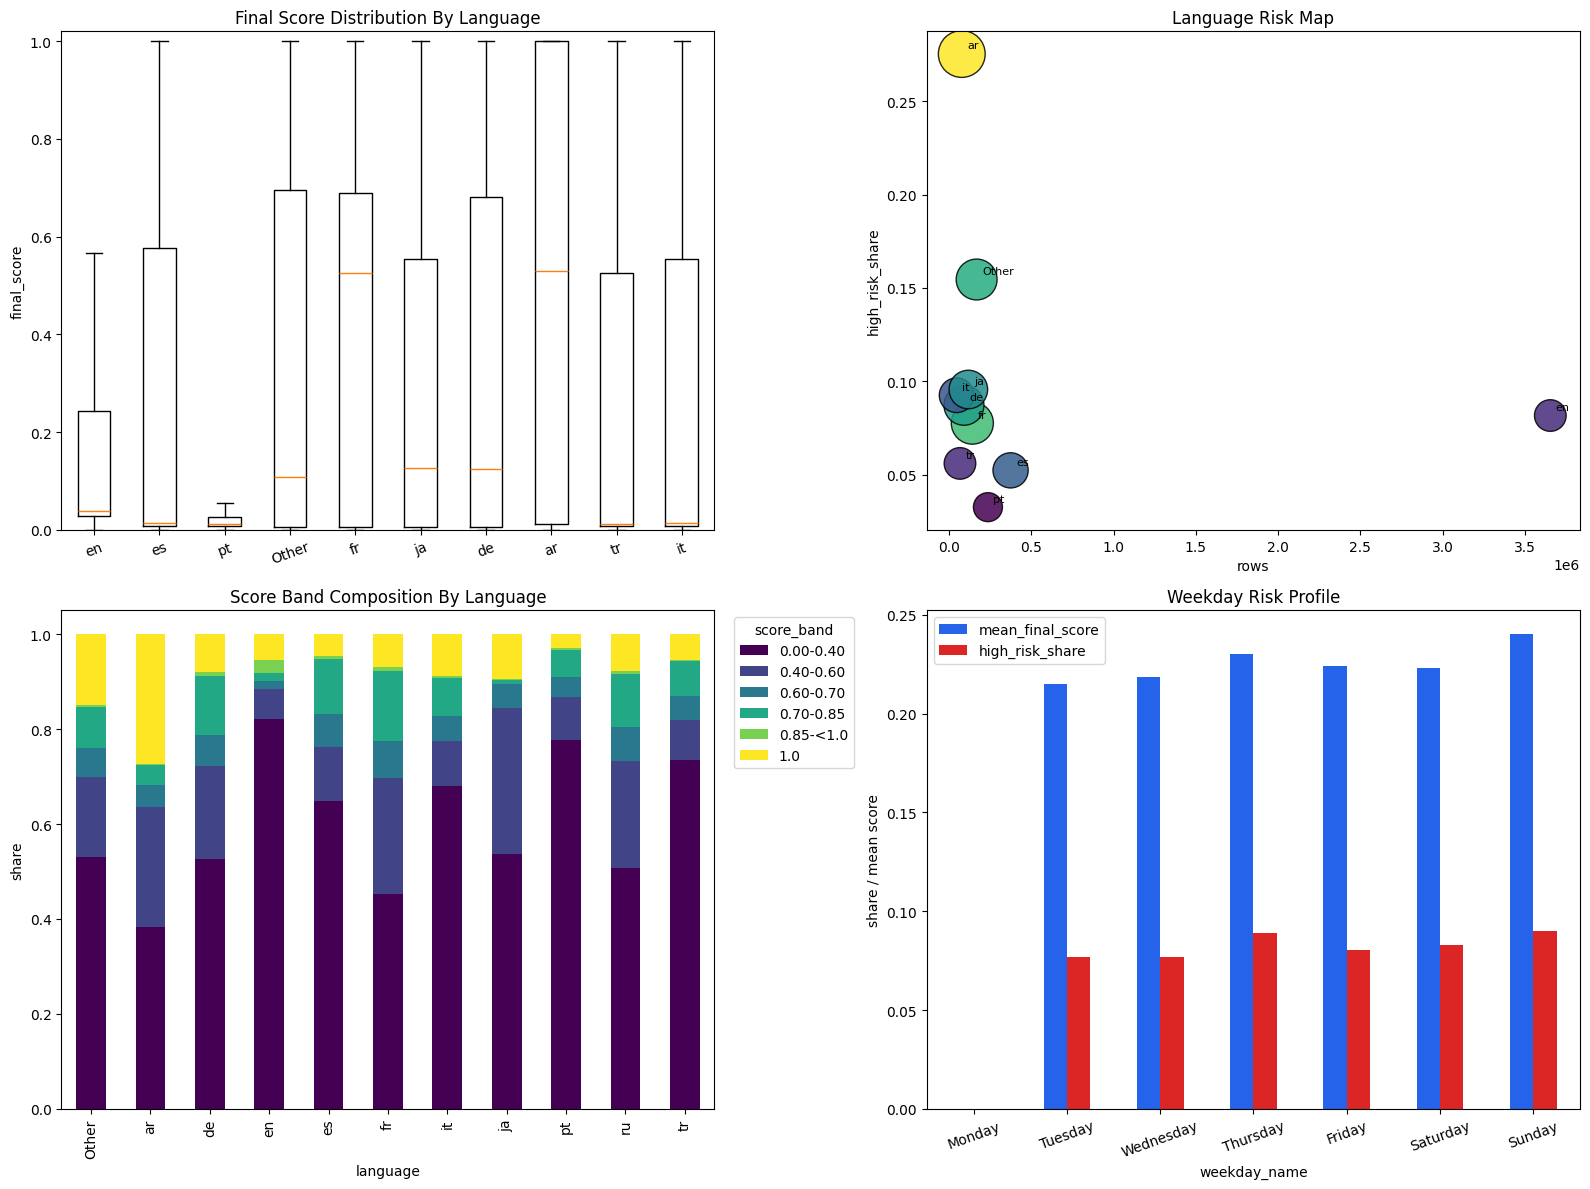

In [107]:
top_languages = language_map_summary.head(10).index.tolist()
language_plot_df = map_df.loc[map_df["language_top"].isin(top_languages)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

lang_box_data = [
    language_plot_df.loc[language_plot_df["language_top"] == language, "final_score"].dropna().sample(
        min(80000, int(language_plot_df.loc[language_plot_df["language_top"] == language, "final_score"].notna().sum())),
        random_state=42,
    )
    for language in top_languages
]
axes[0, 0].boxplot(lang_box_data, labels=top_languages, showfliers=False)
axes[0, 0].set_title("Final Score Distribution By Language")
axes[0, 0].set_ylabel("final_score")
axes[0, 0].set_ylim(0, 1.02)
axes[0, 0].tick_params(axis="x", rotation=20)

language_summary_plot = language_map_summary.head(10).sort_values("high_risk_share")
axes[0, 1].scatter(
    language_summary_plot["rows"],
    language_summary_plot["high_risk_share"],
    s=language_summary_plot["mean_final_score"] * 2200 + 80,
    c=language_summary_plot["mean_final_score"],
    cmap="viridis",
    alpha=0.85,
    edgecolor="black",
)
for label, row in language_summary_plot.iterrows():
    axes[0, 1].annotate(str(label), (row["rows"], row["high_risk_share"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0, 1].set_title("Language Risk Map")
axes[0, 1].set_xlabel("rows")
axes[0, 1].set_ylabel("high_risk_share")

plot_normalized_stack(axes[1, 0], map_df, "language", top_n=10, title="Score Band Composition By Language")

weekday_map_summary[["mean_final_score", "high_risk_share"]].plot(
    kind="bar",
    ax=axes[1, 1],
    color=["#2563eb", "#dc2626"],
)
axes[1, 1].set_title("Weekday Risk Profile")
axes[1, 1].set_ylabel("share / mean score")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()


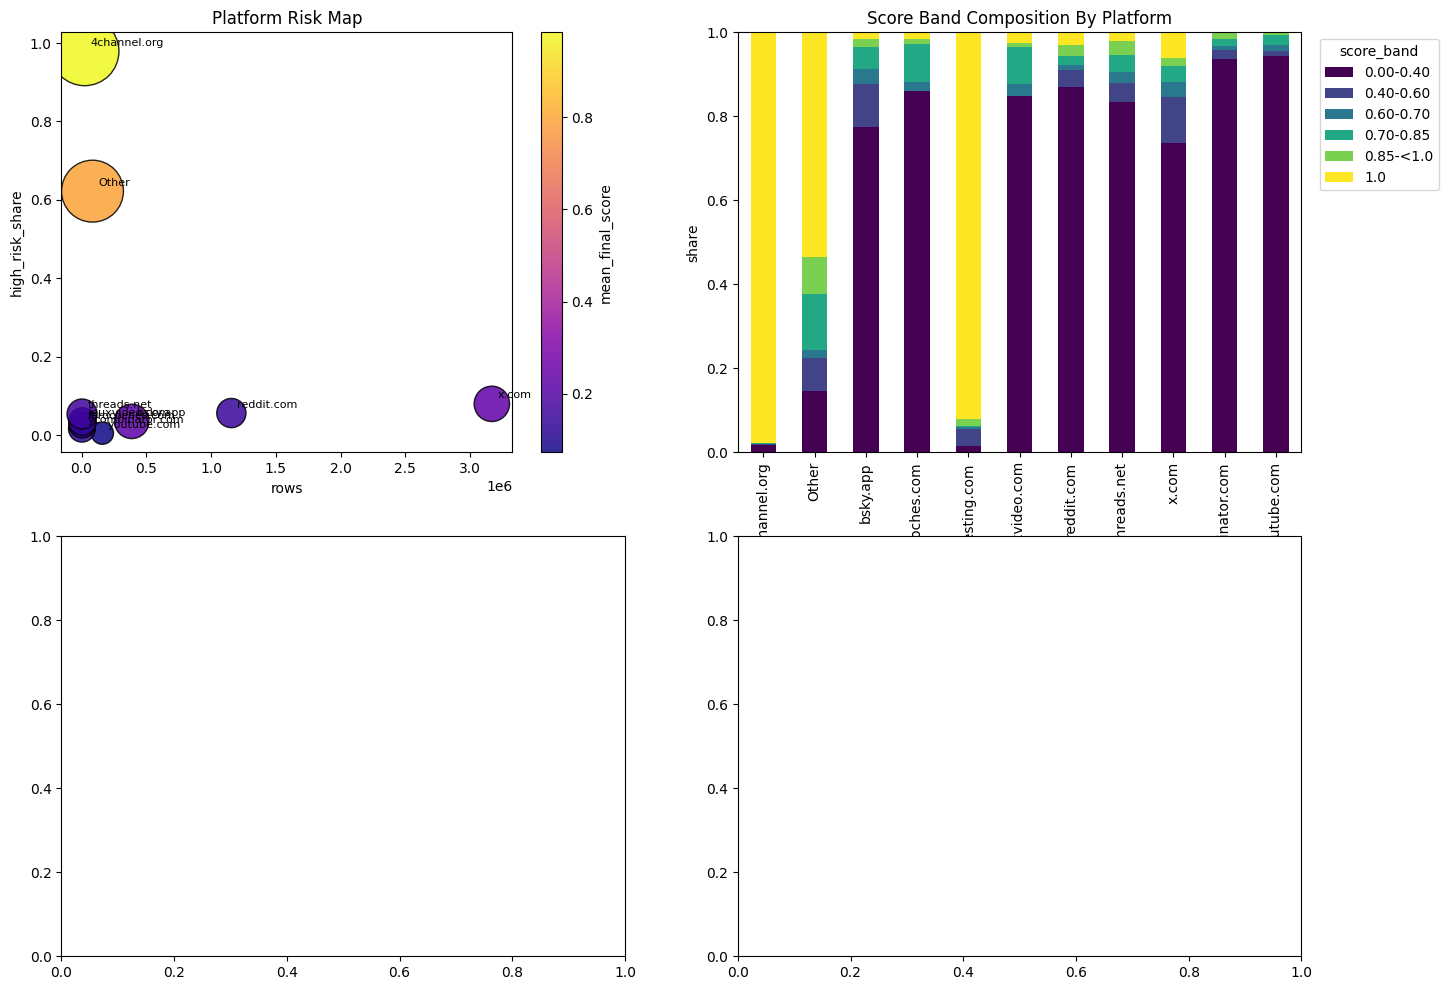

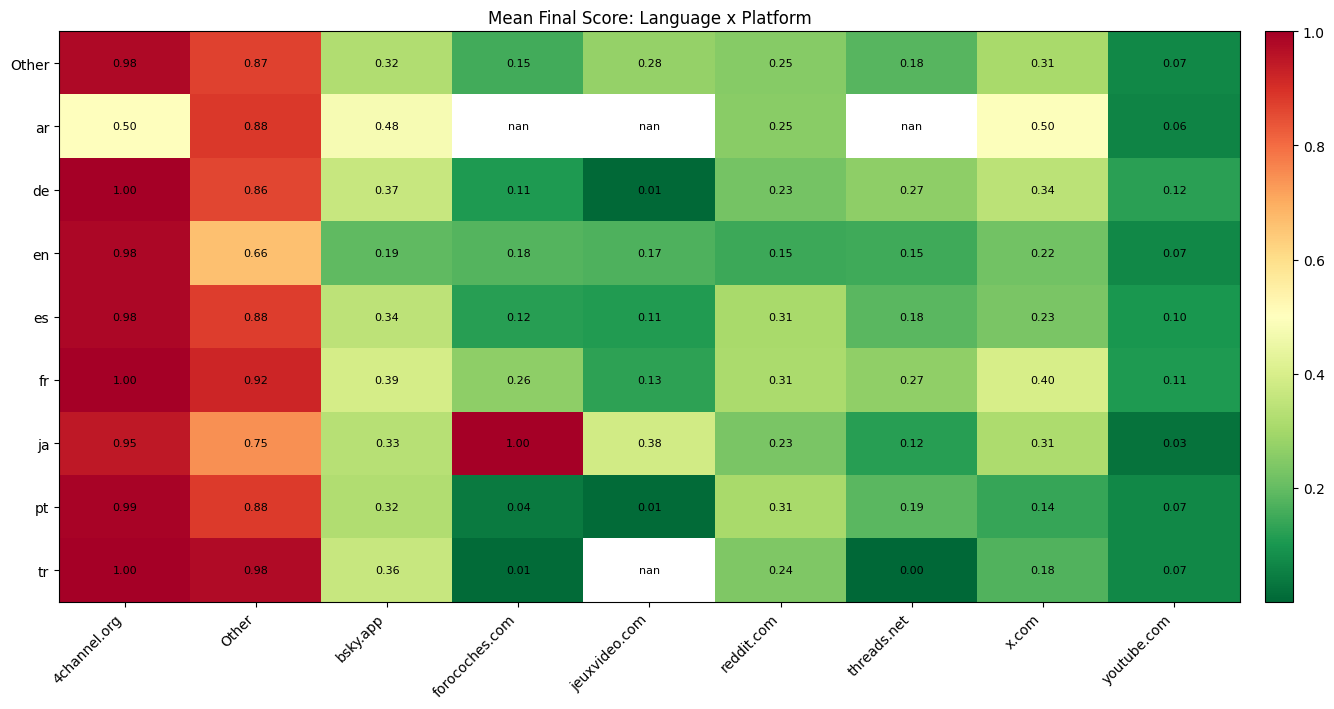

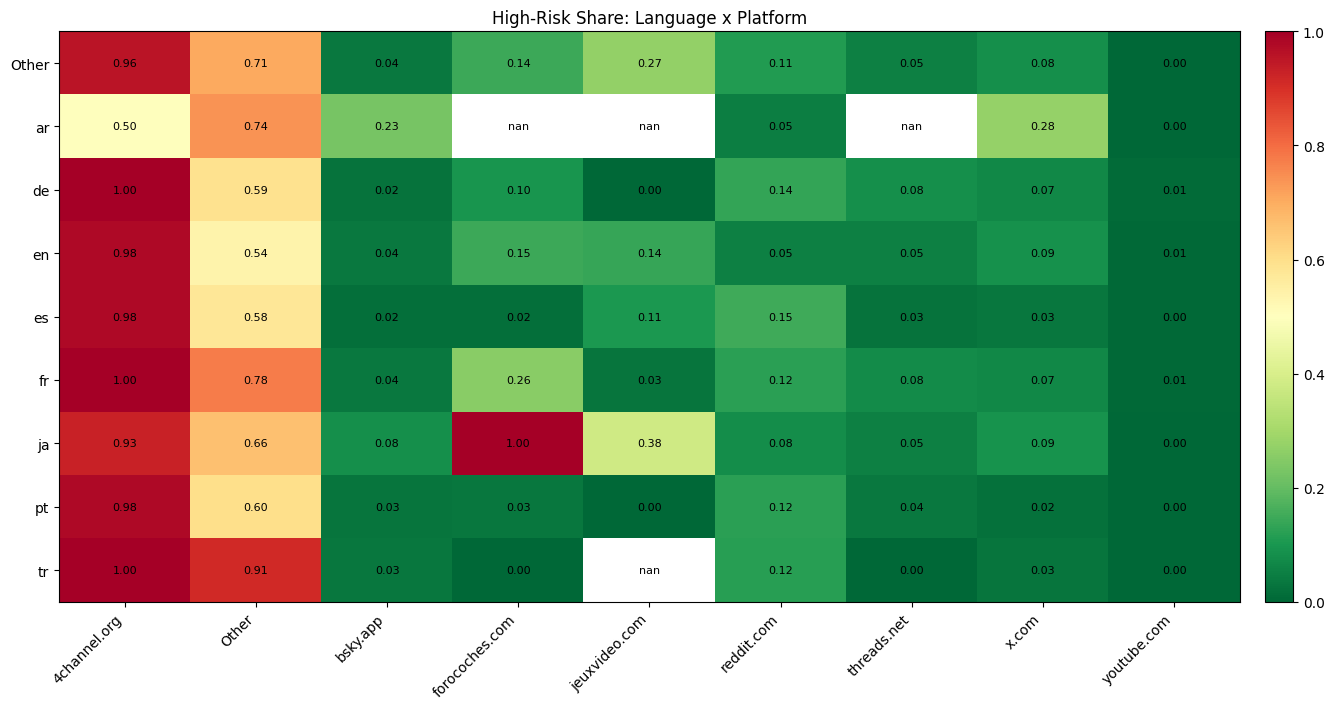

/var/folders/lb/_sf4xmsn3v38zhlnqd793tn00000gn/T/ipykernel_25690/683792127.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(platform_box_data, labels=top_platforms, showfliers=False)


In [114]:
top_platforms = platform_map_summary.head(10).index.tolist()
platform_plot_df = map_df.loc[map_df["platform_top"].isin(top_platforms)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

platform_summary_plot = platform_map_summary.head(10).sort_values("high_risk_share")
scatter = axes[0, 0].scatter(
    platform_summary_plot["rows"],
    platform_summary_plot["high_risk_share"],
    s=platform_summary_plot["mean_final_score"] * 2400 + 80,
    c=platform_summary_plot["mean_final_score"],
    cmap="plasma",
    alpha=0.85,
    edgecolor="black",
)
for label, row in platform_summary_plot.iterrows():
    axes[0, 0].annotate(str(label), (row["rows"], row["high_risk_share"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0, 0].set_title("Platform Risk Map")
axes[0, 0].set_xlabel("rows")
axes[0, 0].set_ylabel("high_risk_share")
fig.colorbar(scatter, ax=axes[0, 0], label="mean_final_score")

plot_normalized_stack(axes[0, 1], map_df, "registered_domain", top_n=10, title="Score Band Composition By Platform")

plot_matrix_heatmap(language_platform_heatmap, "Mean Final Score: Language x Platform", cmap="RdYlGn_r")
plt.show()

plot_matrix_heatmap(language_platform_high_risk, "High-Risk Share: Language x Platform", cmap="RdYlGn_r")
plt.show()

platform_box_data = [
    platform_plot_df.loc[platform_plot_df["platform_top"] == platform, "final_score"].dropna().sample(
        min(80000, int(platform_plot_df.loc[platform_plot_df["platform_top"] == platform, "final_score"].notna().sum())),
        random_state=42,
    )
    for platform in top_platforms
]
axes[1, 0].boxplot(platform_box_data, labels=top_platforms, showfliers=False)
axes[1, 0].set_title("Final Score Distribution By Platform")
axes[1, 0].set_ylabel("final_score")
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].tick_params(axis="x", rotation=20)

author_type_platform = pd.crosstab(map_df["author_type"], map_df["platform_top"], normalize="index")
author_type_platform.loc[:, author_type_platform.sum(axis=0).sort_values(ascending=False).head(8).index].plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 1],
    colormap="tab20",
)
axes[1, 1].set_title("Author Type Platform Mix")
axes[1, 1].set_ylabel("share")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].legend(title="platform_top", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()


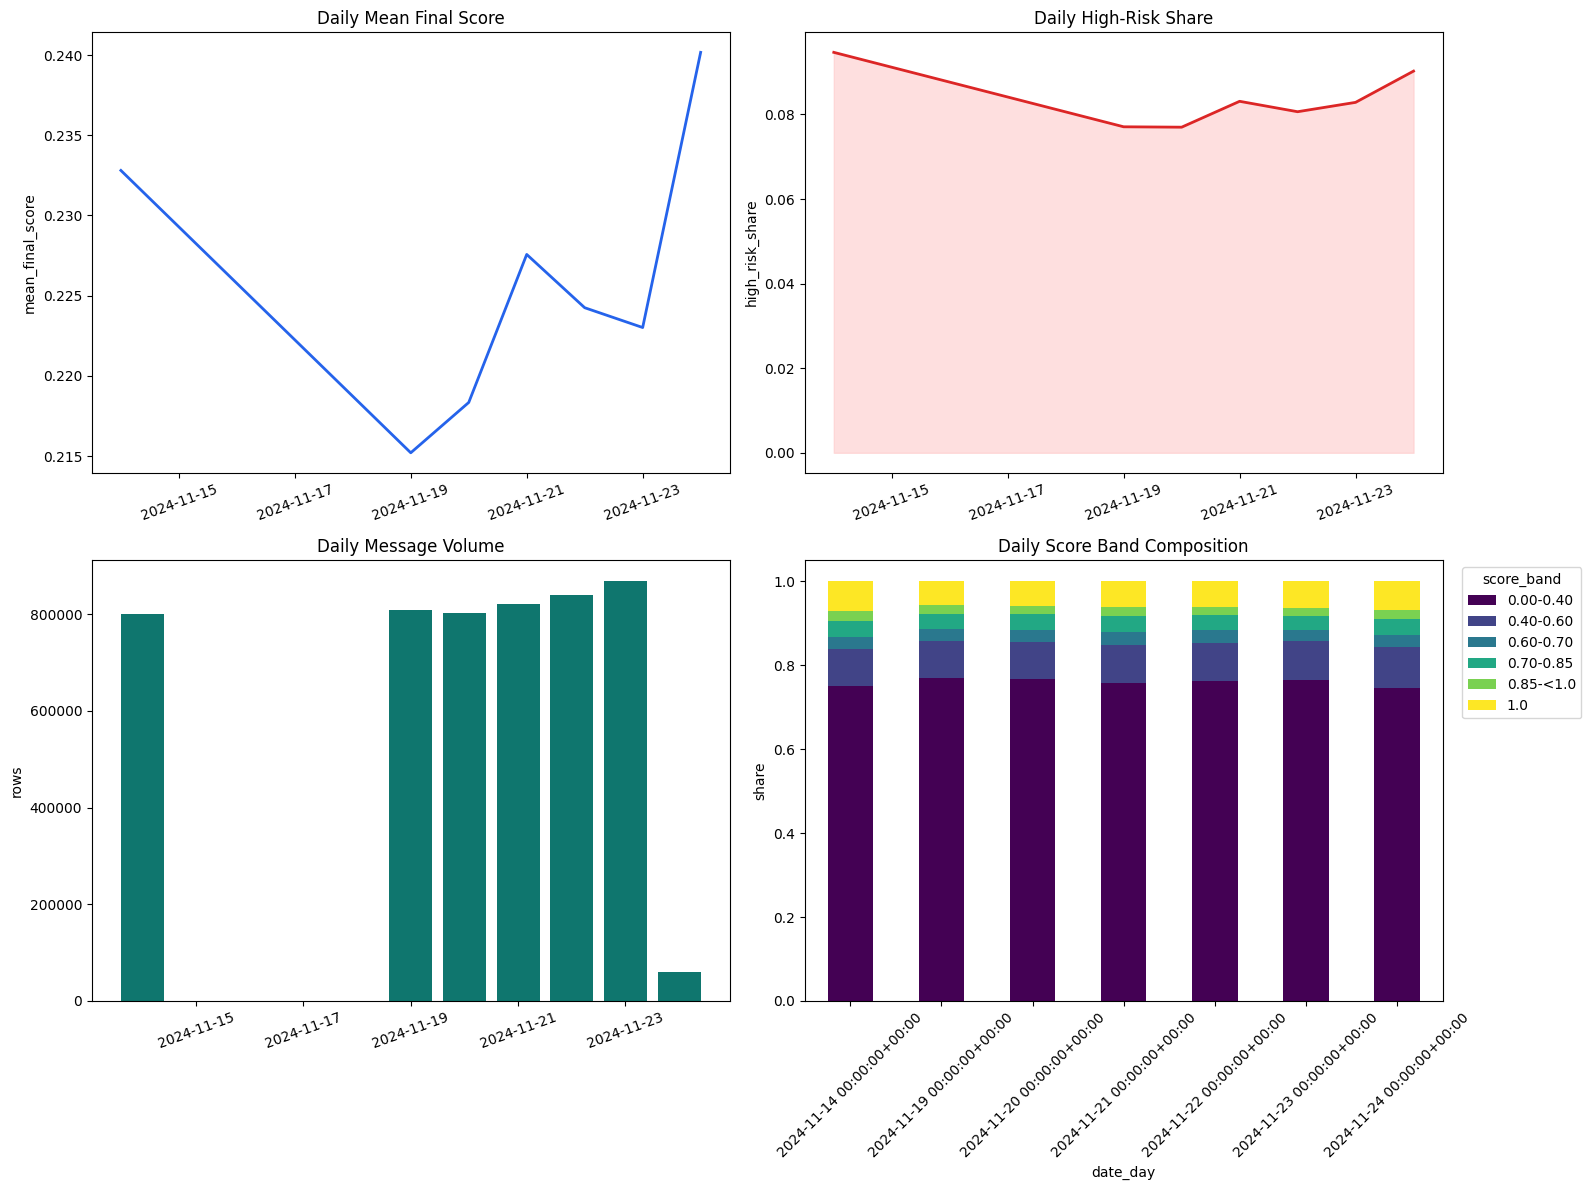

In [111]:
daily_plot_df = daily_map_summary.copy()
daily_plot_df["date_day_str"] = daily_plot_df["date_day"].dt.strftime("%Y-%m-%d")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(daily_plot_df["date_day"], daily_plot_df["mean_final_score"], color="#2563eb", linewidth=2)
axes[0, 0].set_title("Daily Mean Final Score")
axes[0, 0].set_ylabel("mean_final_score")
axes[0, 0].tick_params(axis="x", rotation=20)

axes[0, 1].plot(daily_plot_df["date_day"], daily_plot_df["high_risk_share"], color="#dc2626", linewidth=2)
axes[0, 1].fill_between(daily_plot_df["date_day"], daily_plot_df["high_risk_share"], color="#fecaca", alpha=0.6)
axes[0, 1].set_title("Daily High-Risk Share")
axes[0, 1].set_ylabel("high_risk_share")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].bar(daily_plot_df["date_day"], daily_plot_df["rows"], color="#0f766e")
axes[1, 0].set_title("Daily Message Volume")
axes[1, 0].set_ylabel("rows")
axes[1, 0].tick_params(axis="x", rotation=20)

if len(daily_plot_df) <= 40:
    date_band_share = pd.crosstab(map_df["date_day"], map_df["score_band"], normalize="index").reindex(columns=SCORE_BAND_LABELS, fill_value=0.0)
    date_band_share.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="viridis")
    axes[1, 1].set_title("Daily Score Band Composition")
    axes[1, 1].set_ylabel("share")
    axes[1, 1].tick_params(axis="x", rotation=45)
    axes[1, 1].legend(title="score_band", bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    top_days = daily_plot_df.sort_values("high_risk_share", ascending=False).head(20)["date_day"]
    top_day_df = map_df.loc[map_df["date_day"].isin(top_days)].copy()
    top_day_df["date_day_label"] = top_day_df["date_day"].dt.strftime("%Y-%m-%d")
    date_band_share = pd.crosstab(top_day_df["date_day_label"], top_day_df["score_band"], normalize="index").reindex(columns=SCORE_BAND_LABELS, fill_value=0.0)
    date_band_share.plot(kind="barh", stacked=True, ax=axes[1, 1], colormap="viridis")
    axes[1, 1].set_title("Top 20 High-Risk Days: Score Band Mix")
    axes[1, 1].set_xlabel("share")
    axes[1, 1].set_ylabel("date_day")
    axes[1, 1].legend(title="score_band", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()
